import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import re

sns.set_theme(style='whitegrid')


## Init

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import re

sns.set_theme(style='whitegrid')


In [32]:
### load and aggregate all experiment csvs
RESULTS_DIR = 'results'
TCP_COL = 'unweighted_tcp_score'
csv_files = sorted(glob.glob(f'{RESULTS_DIR}/*/*/*.csv'))
print(f'found {len(csv_files)} result files')
### known strategies - order matters for matching multi-token names first
STRATEGY_LIST = [
    'proportional_50', 'proportional_100', 'proportional_200',
    'margin_10_40', 'margin_20_50', 'margin_30_60',
    'simple_25', 'simple_50', 'simple_75', 'neutral',
]
CLASS_MAP = {
    'proportional': 'Proportional',
    'margin': 'Margin',
    'simple': 'Simple',
    'neutral': 'Baseline',
}
summary_rows = []
trace_frames = []  # flat list, no dict key collision
for fpath in csv_files:
    df = pd.read_csv(fpath)
    basename = os.path.basename(fpath)
    ### parse objective (tcp or cs)
    objective = 'unknown'
    if 'tcp/' in fpath: objective = 'tcp'
    elif 'cs/' in fpath: objective = 'cs'
    ### parse surcharges from directory name
    m = re.search(r'county_(\d+)_coi_(\d+)', fpath)
    county_surcharge = int(m.group(1)) if m else 0
    coi_surcharge = int(m.group(2)) if m else 100
    ### match strategy name
    strategy = 'unknown'
    strategy_class = 'Other'
    for s in STRATEGY_LIST:
        if s in basename:
            strategy = s
            strategy_class = CLASS_MAP[s.split('_')[0]]
            break
    ### surcharge label for plotting (e.g. "county 0 / coi 100")
    v_match = re.search(r'_v(\d+)\.csv', fpath)
    replica = f'v{v_match.group(1)}' if v_match else 'v1'
    surcharge_label = f'county {county_surcharge} / coi {coi_surcharge}'
    summary_rows.append({
        'objective': objective,
        'strategy': strategy,
        'strategy_class': strategy_class,
        'county_surcharge': county_surcharge,
        'coi_surcharge': coi_surcharge,
        'surcharge_label': surcharge_label,
        'mean_tcp': df[TCP_COL].mean(),
        'max_tcp': df[TCP_COL].max(),
        'min_tcp': df[TCP_COL].min(),
        'mean_county_splits': df['county_split_count'].mean(),
        
    })
    ### thin trace to every 100th row for plotting
    if 'accepted' in df.columns:
        df['rolling_accept_rate'] = df['accepted'].rolling(1000, min_periods=1).mean()
    else:
        is_accepted = (df[TCP_COL].diff() != 0) | (df['county_split_count'].diff() != 0)
        df['rolling_accept_rate'] = is_accepted.astype(int).rolling(1000, min_periods=1).mean()
    cols_to_keep = ['step', TCP_COL, 'county_split_count', 'rolling_accept_rate', 'communities_split']
    if 'dem_wins' in df.columns:
        cols_to_keep.append('dem_wins')
    share_cols = [c for c in df.columns if 'dem_share' in c]
    cols_to_keep.extend(share_cols)
    t = df[cols_to_keep].iloc[::100].copy()
    if share_cols:
        t['mean_dem_share'] = t[share_cols].mean(axis=1)
    t['strategy'] = strategy
    t['strategy_class'] = strategy_class
    t['county_surcharge'] = county_surcharge
    t['coi_surcharge'] = coi_surcharge
    t['surcharge_label'] = surcharge_label
    t['replica'] = replica
    t['objective'] = objective
    trace_frames.append(t)
master_df = pd.DataFrame(summary_rows)
traces = pd.concat(trace_frames, ignore_index=True)
### enforce ordering
CLASS_ORDER = ['Proportional', 'Margin', 'Simple', 'Baseline']
traces['strategy_class'] = pd.Categorical(traces['strategy_class'], categories=CLASS_ORDER, ordered=True)
import re
surcharge_order = sorted(traces['surcharge_label'].unique(), key=lambda x: int(re.search(r'county (\d+)', x).group(1)), reverse=True)
traces['surcharge_label'] = pd.Categorical(traces['surcharge_label'], categories=surcharge_order, ordered=True)
print(f'loaded {len(master_df)} runs across {traces["surcharge_label"].nunique()} surcharge configs')
display(master_df.head(10))


found 116 result files
loaded 116 runs across 3 surcharge configs


,objective,strategy,strategy_class,county_surcharge,coi_surcharge,surcharge_label,mean_tcp,max_tcp,min_tcp,mean_county_splits
0,cs,margin_10_40,Margin,100,0,county 100 / coi 0,0.925616,0.948016,0.800141,5.61943
1,cs,margin_10_40,Margin,100,0,county 100 / coi 0,0.927569,0.947819,0.814344,5.72922
2,cs,margin_20_50,Margin,100,0,county 100 / coi 0,0.918421,0.948047,0.816149,5.65346
3,cs,margin_20_50,Margin,100,0,county 100 / coi 0,0.919730,0.947972,0.797358,5.53724
4,cs,margin_30_60,Margin,100,0,county 100 / coi 0,0.918268,0.947231,0.790801,5.56847
5,cs,margin_30_60,Margin,100,0,county 100 / coi 0,0.919159,0.947972,0.811965,5.63447
6,cs,neutral,Baseline,100,0,county 100 / coi 0,0.884494,0.945795,0.737430,5.85095
7,cs,neutral,Baseline,100,0,county 100 / coi 0,0.885915,0.945893,0.758777,5.81516
8,cs,proportional_100,Proportional,100,0,county 100 / coi 0,0.919908,0.946922,0.850322,5.53769
9,cs,proportional_100,Proportional,100,0,county 100 / coi 0,0.920537,0.946305,0.820525,5.53301


## Rolling Acceptance Rate

the acceptance rate is the proportion of proposed maps that are accepted over a rolling window of 1,000 chain steps.

a healthy mcmc chain should maintain acceptance rates roughly between 5% and 20%.
- below 5%: the chain is frozen in a local maximum and rejecting almost everything.
- above 20%: the chain is accepting too many degraded maps (acting like a random walk).


### Objective: TCP

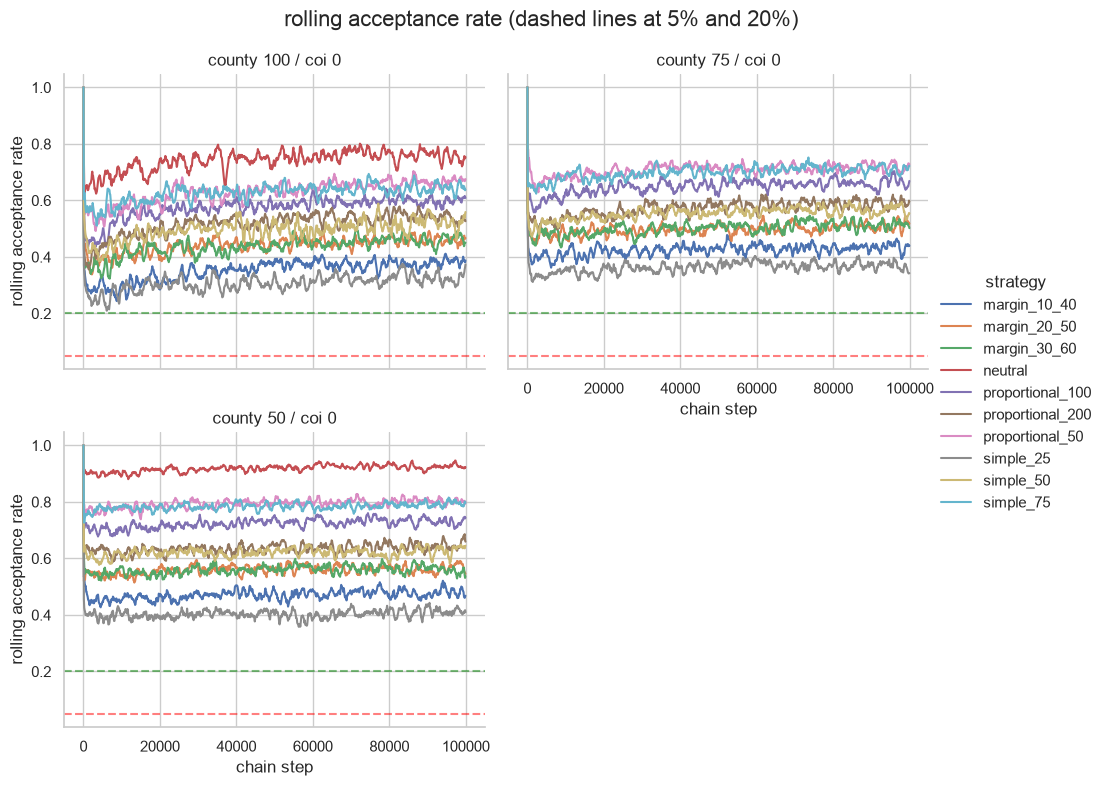

In [33]:
obj_traces = traces[traces['objective'] == 'tcp']
if len(obj_traces) > 0:
    ### rolling acceptance rate by strategy, faceted by surcharge configuration
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    grouped_accept = obj_traces.groupby(['step', 'surcharge_label', 'strategy'], observed=True)['rolling_accept_rate'].mean().reset_index()
    
    g = sns.relplot(
        data=grouped_accept,
        x="step",
        y="rolling_accept_rate",
        hue="strategy",
        col="surcharge_label",
        kind="line",
        height=4,
        aspect=1.2,
        col_wrap=2
    )
    
    for ax in g.axes.flat:
        ax.axhline(0.05, color='red', linestyle='--', alpha=0.5)
        ax.axhline(0.20, color='green', linestyle='--', alpha=0.5)
    
    g.set_axis_labels("chain step", "rolling acceptance rate")
    g.set_titles(col_template="{col_name}")
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle("rolling acceptance rate (dashed lines at 5% and 20%)", fontsize=16)
    plt.show()
    
    

### Objective: CS

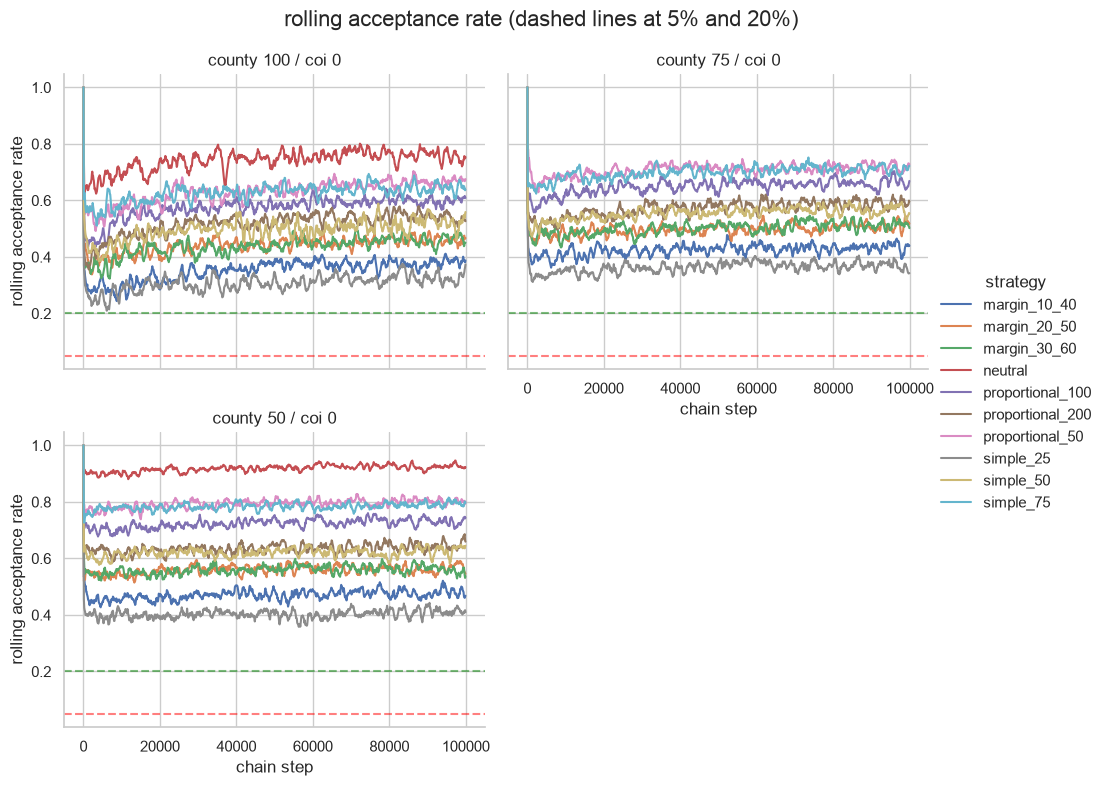

In [34]:
obj_traces = traces[traces['objective'] == 'cs']
if len(obj_traces) > 0:
    ### rolling acceptance rate by strategy, faceted by surcharge configuration
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    grouped_accept = obj_traces.groupby(['step', 'surcharge_label', 'strategy'], observed=True)['rolling_accept_rate'].mean().reset_index()
    
    g = sns.relplot(
        data=grouped_accept,
        x="step",
        y="rolling_accept_rate",
        hue="strategy",
        col="surcharge_label",
        kind="line",
        height=4,
        aspect=1.2,
        col_wrap=2
    )
    
    for ax in g.axes.flat:
        ax.axhline(0.05, color='red', linestyle='--', alpha=0.5)
        ax.axhline(0.20, color='green', linestyle='--', alpha=0.5)
    
    g.set_axis_labels("chain step", "rolling acceptance rate")
    g.set_titles(col_template="{col_name}")
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle("rolling acceptance rate (dashed lines at 5% and 20%)", fontsize=16)
    plt.show()
    
    

## Pareto Frontier: TCP vs County Splits

tradeoff: we want to maximize coi preservation (tcp) while minimizing county splits. so, the ideal maps are sit in the **top-left corner of the plots.**


### Objective: TCP

In [ ]:
obj_traces = traces[traces['objective'] == 'tcp']
if len(obj_traces) > 0:
    ### pareto frontier: tcp vs county splits
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    g = sns.FacetGrid(
        obj_traces,
        row="surcharge_label",
        col="strategy",
    )
    g.map_dataframe(sns.histplot, x="county_split_count", y=TCP_COL, fill=True, alpha=0.7, cmap="Blues", linewidths=0)
    g.map(plt.scatter, x=[9], y=[0.92], color="red", s=30, zorder=10, label="Enacted Plan")
    
    g.set_axis_labels("county splits", "tcp score")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle("pareto frontier: tcp vs county splits (top-left is best)\nred dot = enacted plan", fontsize=16)
    plt.show()
    
    

### Objective: CS

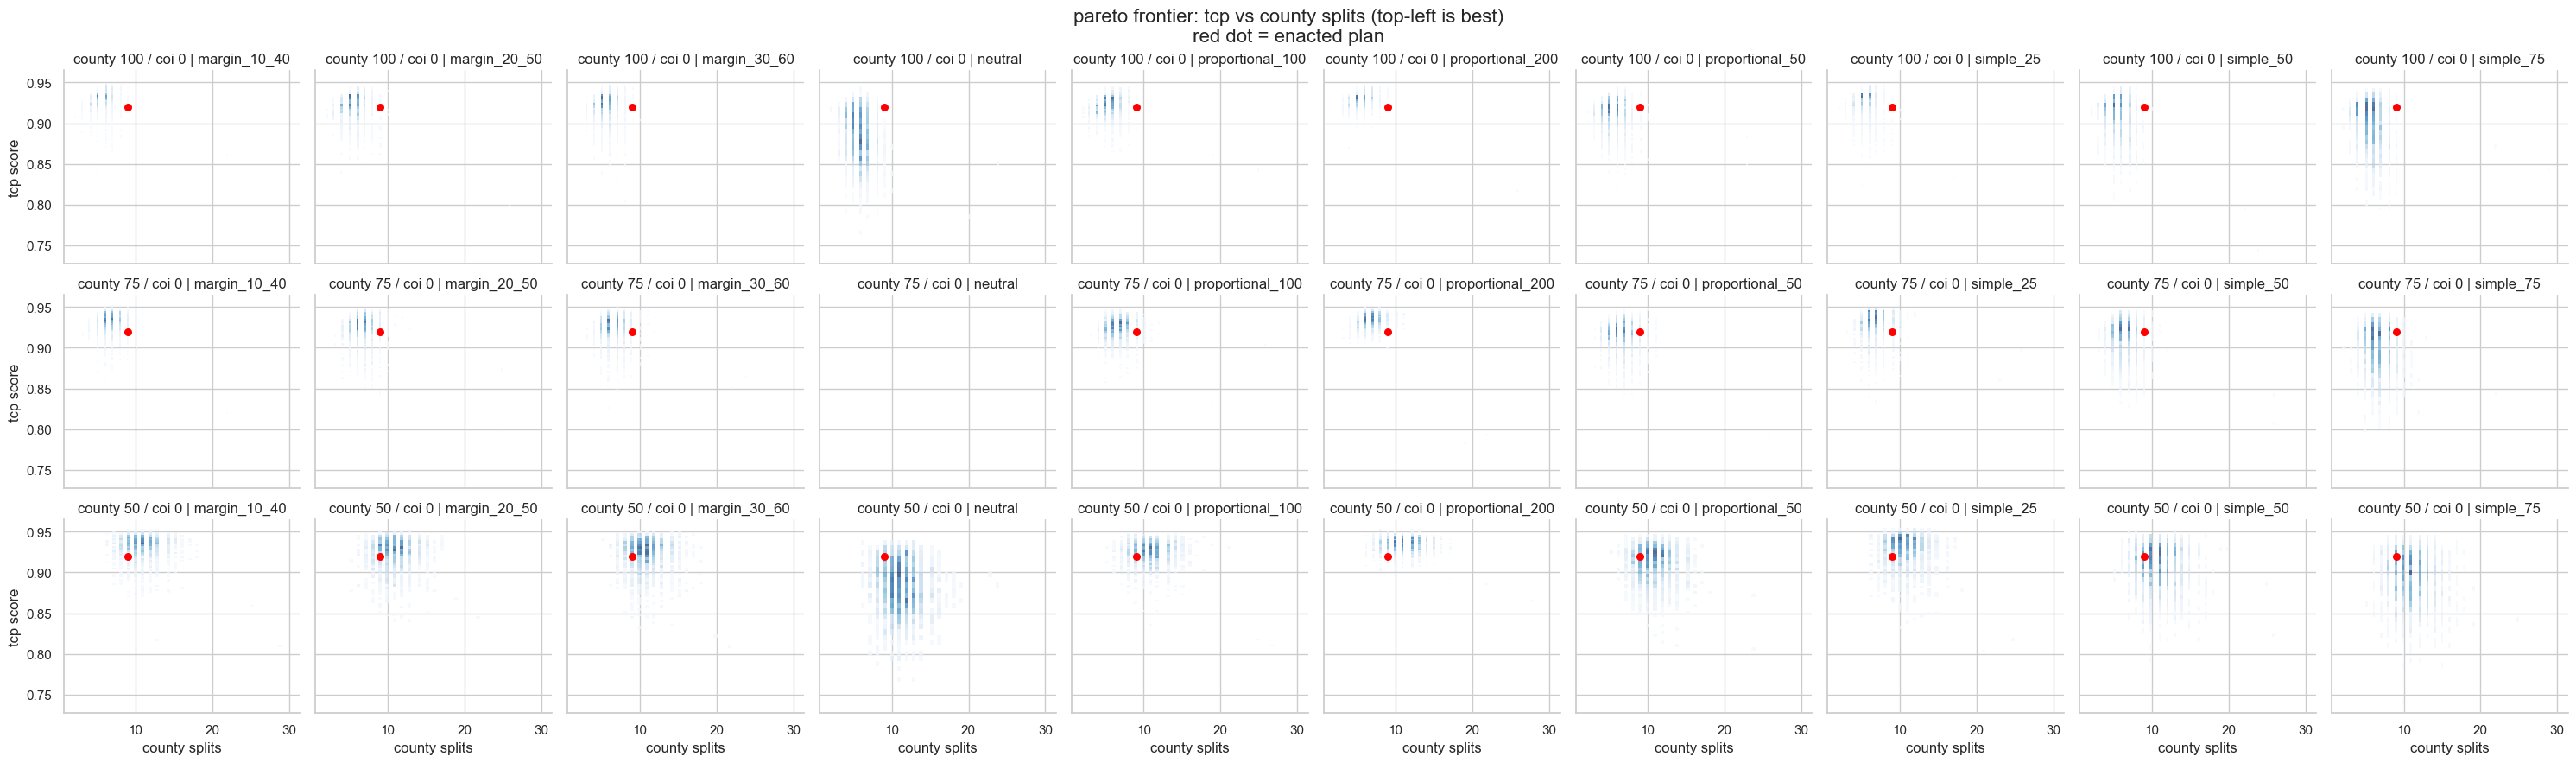

In [ ]:
obj_traces = traces[traces['objective'] == 'cs']
if len(obj_traces) > 0:
    ### pareto frontier: tcp vs county splits
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    g = sns.FacetGrid(
        obj_traces,
        row="surcharge_label",
        col="strategy",
    )
    g.map_dataframe(sns.histplot, x="county_split_count", y=TCP_COL, fill=True, alpha=0.7, cmap="Blues", linewidths=0)
    g.map(plt.scatter, x=[9], y=[0.92], color="red", s=30, zorder=10, label="Enacted Plan")
    
    g.set_axis_labels("county splits", "tcp score")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle("pareto frontier: tcp vs county splits (top-left is best)\nred dot = enacted plan", fontsize=16)
    plt.show()
    
    

## TCP Over Steps

how does tcp evolve as the chain runs? smooth, stabilizing climbs suggest
realistic optimization. erratic swings suggest the acceptance function is
too loose or too tight.




### Objective: TCP

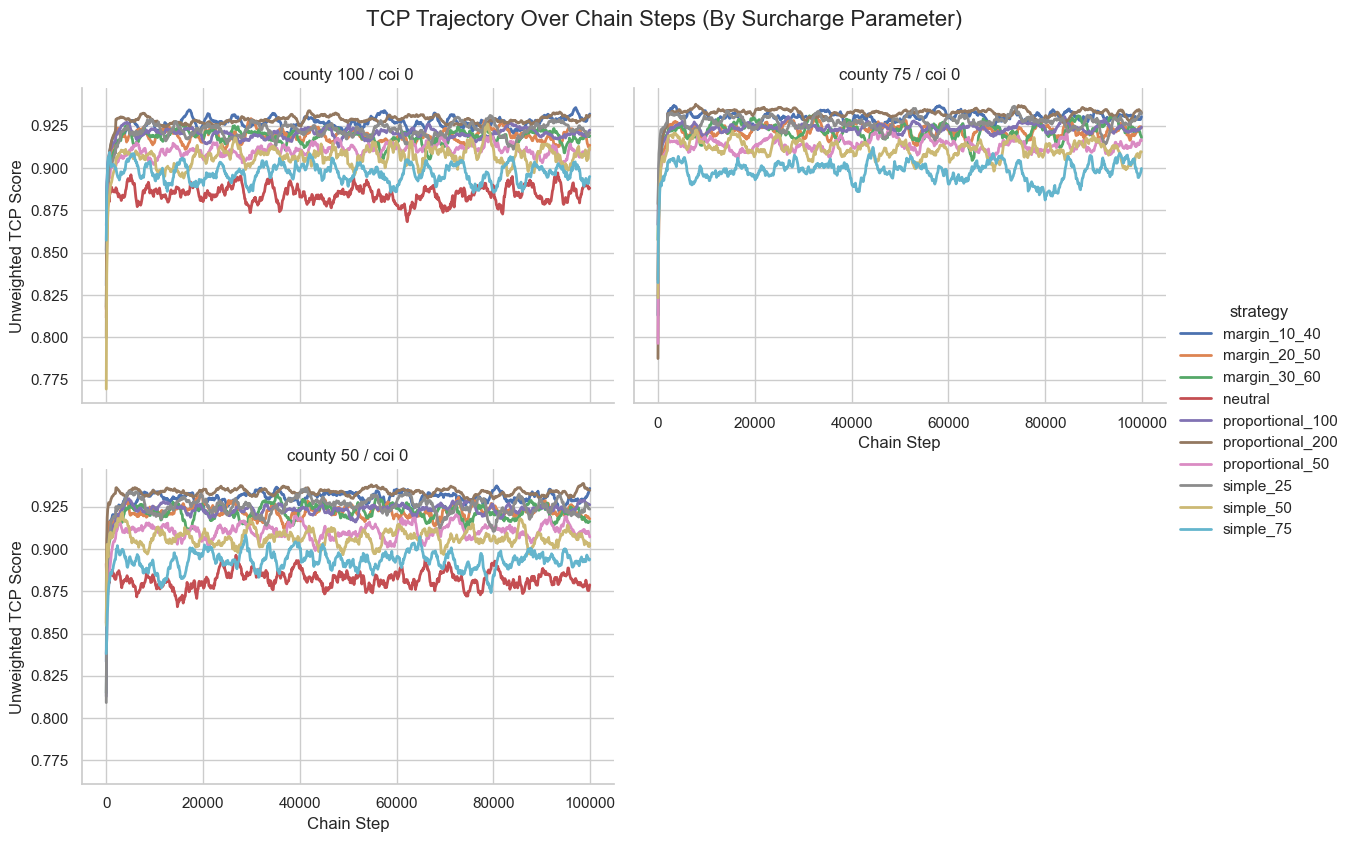

In [ ]:
obj_traces = traces[traces['objective'] == 'tcp']
if len(obj_traces) > 0:
    ### tcp trajectory by strategy, faceted by surcharge config
    grouped_obj_traces = obj_traces.groupby(['step', 'surcharge_label', 'strategy'], observed=True).mean(numeric_only=True).reset_index()
    grouped_obj_traces = grouped_obj_traces.sort_values(['surcharge_label', 'strategy', 'step'])
    grouped_obj_traces[TCP_COL] = grouped_obj_traces.groupby(['surcharge_label', 'strategy'], observed=True)[TCP_COL].transform(lambda x: x.rolling(20, min_periods=1).mean())
    g = sns.relplot(
        data=grouped_obj_traces,
        x='step',
        y=TCP_COL,
        hue='strategy',
        col='surcharge_label',
        col_wrap=2,
        kind='line',
        height=4,
        aspect=1.5,
        linewidth=2
    )
    g.set_axis_labels('Chain Step', 'Unweighted TCP Score')
    g.set_titles('{col_name}')
    g.fig.suptitle('TCP Trajectory Over Chain Steps (By Surcharge Parameter)', y=1.05, fontsize=16)
    plt.show()
    
    

### Objective: CS

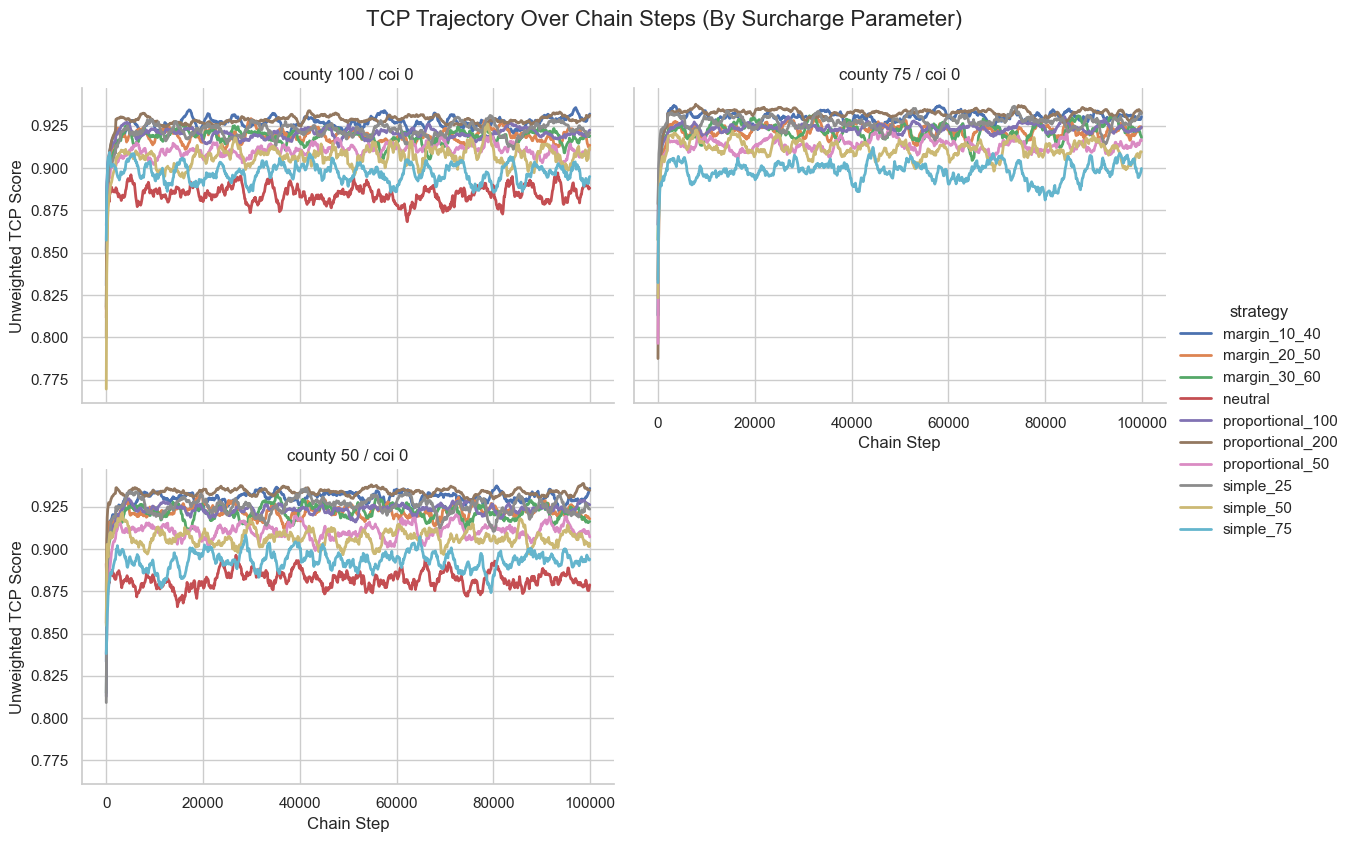

In [ ]:
obj_traces = traces[traces['objective'] == 'cs']
if len(obj_traces) > 0:
    ### tcp trajectory by strategy, faceted by surcharge config
    grouped_obj_traces = obj_traces.groupby(['step', 'surcharge_label', 'strategy'], observed=True).mean(numeric_only=True).reset_index()
    grouped_obj_traces = grouped_obj_traces.sort_values(['surcharge_label', 'strategy', 'step'])
    grouped_obj_traces[TCP_COL] = grouped_obj_traces.groupby(['surcharge_label', 'strategy'], observed=True)[TCP_COL].transform(lambda x: x.rolling(20, min_periods=1).mean())
    g = sns.relplot(
        data=grouped_obj_traces,
        x='step',
        y=TCP_COL,
        hue='strategy',
        col='surcharge_label',
        col_wrap=2,
        kind='line',
        height=4,
        aspect=1.5,
        linewidth=2
    )
    g.set_axis_labels('Chain Step', 'Unweighted TCP Score')
    g.set_titles('{col_name}')
    g.fig.suptitle('TCP Trajectory Over Chain Steps (By Surcharge Parameter)', y=1.05, fontsize=16)
    plt.show()
    
    

### Objective: TCP

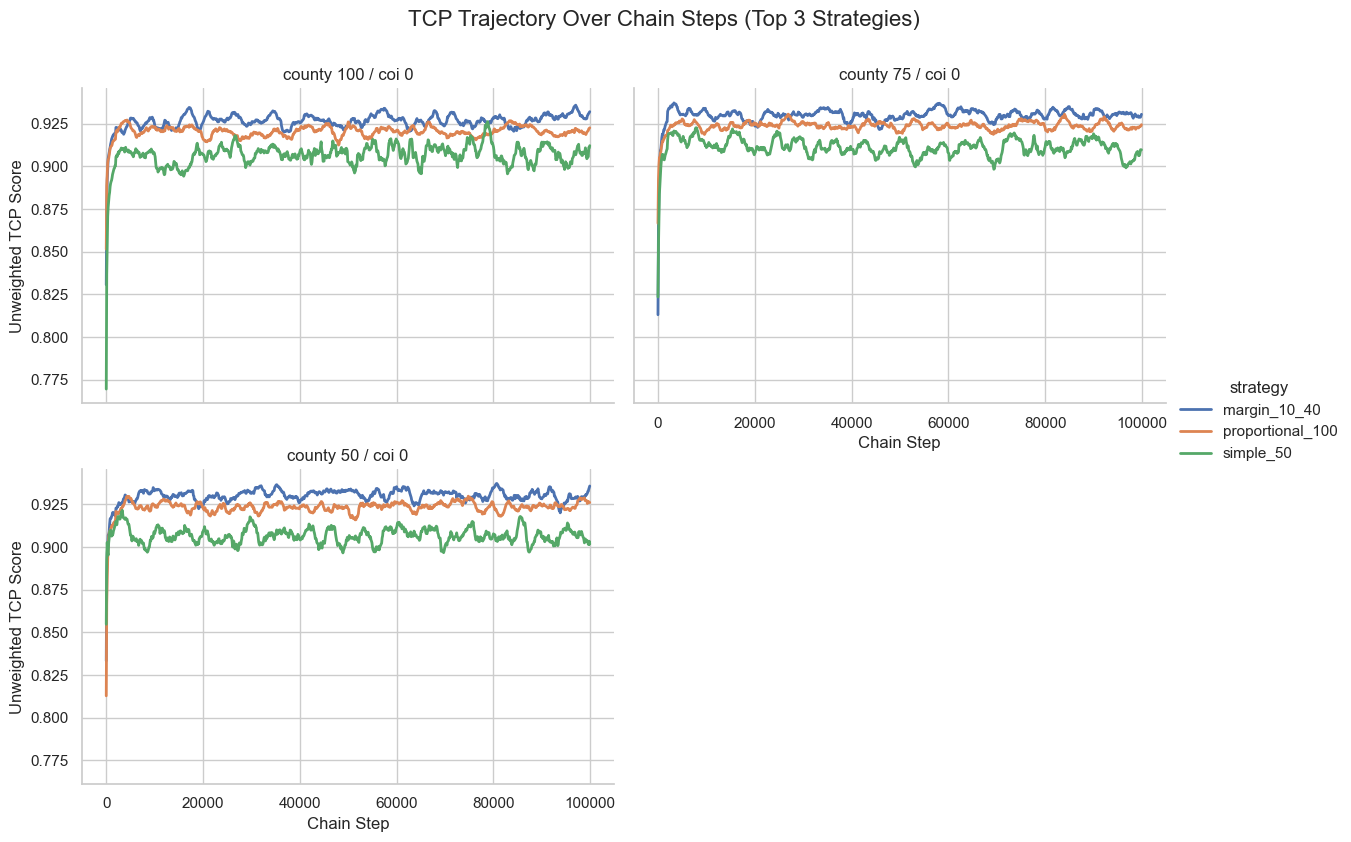

In [ ]:
obj_traces = traces[traces['objective'] == 'tcp']
if len(obj_traces) > 0:
    # filter based on the top 3 we think we like
    top_strategies = ['margin_10_40', 'proportional_100', 'simple_50']
    filtered_obj_traces = obj_traces[obj_traces['strategy'].isin(top_strategies)].copy()
    grouped_obj_traces = filtered_obj_traces.groupby(['step', 'surcharge_label', 'strategy'], observed=True).mean(numeric_only=True).reset_index()
    grouped_obj_traces = grouped_obj_traces.sort_values(['surcharge_label', 'strategy', 'step'])
    grouped_obj_traces[TCP_COL] = grouped_obj_traces.groupby(['surcharge_label', 'strategy'], observed=True)[TCP_COL].transform(lambda x: x.rolling(20, min_periods=1).mean())
    # 3. Plot with thicker lines and a distinct color palette
    g = sns.relplot(
        data=grouped_obj_traces,
        x='step',
        y=TCP_COL,
        hue='strategy',
        col='surcharge_label',
        col_wrap=2,
        kind='line',
        height=4,
        aspect=1.5,
        linewidth=2,
    )
    g.set_axis_labels('Chain Step', 'Unweighted TCP Score')
    g.set_titles('{col_name}')
    g.fig.suptitle('TCP Trajectory Over Chain Steps (Top 3 Strategies)', y=1.05, fontsize=16)
    plt.show()
    
    

### Objective: CS

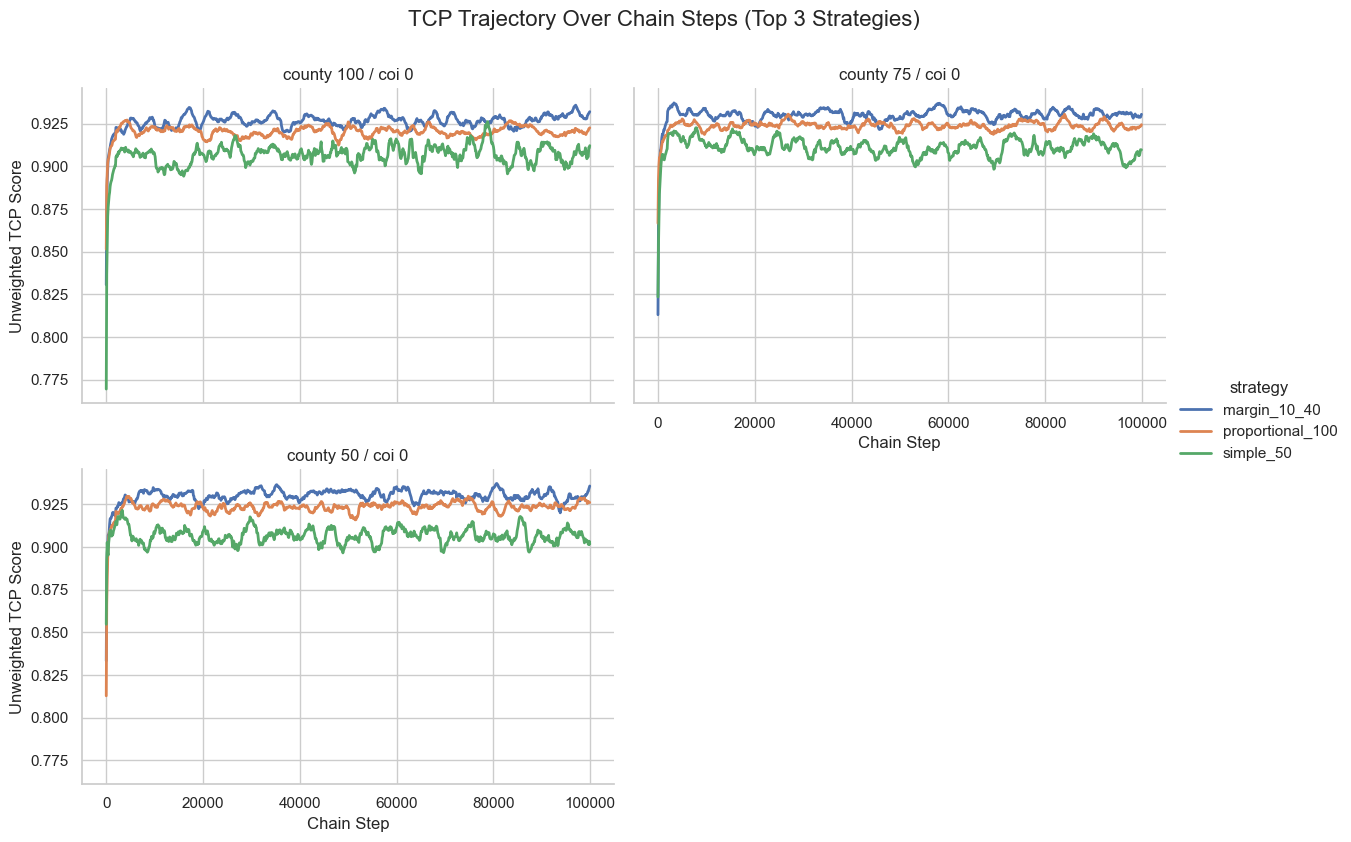

In [ ]:
obj_traces = traces[traces['objective'] == 'cs']
if len(obj_traces) > 0:
    # filter based on the top 3 we think we like
    top_strategies = ['margin_10_40', 'proportional_100', 'simple_50']
    filtered_obj_traces = obj_traces[obj_traces['strategy'].isin(top_strategies)].copy()
    grouped_obj_traces = filtered_obj_traces.groupby(['step', 'surcharge_label', 'strategy'], observed=True).mean(numeric_only=True).reset_index()
    grouped_obj_traces = grouped_obj_traces.sort_values(['surcharge_label', 'strategy', 'step'])
    grouped_obj_traces[TCP_COL] = grouped_obj_traces.groupby(['surcharge_label', 'strategy'], observed=True)[TCP_COL].transform(lambda x: x.rolling(20, min_periods=1).mean())
    # 3. Plot with thicker lines and a distinct color palette
    g = sns.relplot(
        data=grouped_obj_traces,
        x='step',
        y=TCP_COL,
        hue='strategy',
        col='surcharge_label',
        col_wrap=2,
        kind='line',
        height=4,
        aspect=1.5,
        linewidth=2,
    )
    g.set_axis_labels('Chain Step', 'Unweighted TCP Score')
    g.set_titles('{col_name}')
    g.fig.suptitle('TCP Trajectory Over Chain Steps (Top 3 Strategies)', y=1.05, fontsize=16)
    plt.show()
    
    

## TCP Distributions By Strategy, Surcharge

we are looking for a strategy with a high median line and a fat upper body, indicating it consistently finds and preserves high-tcp maps.


### Objective: TCP

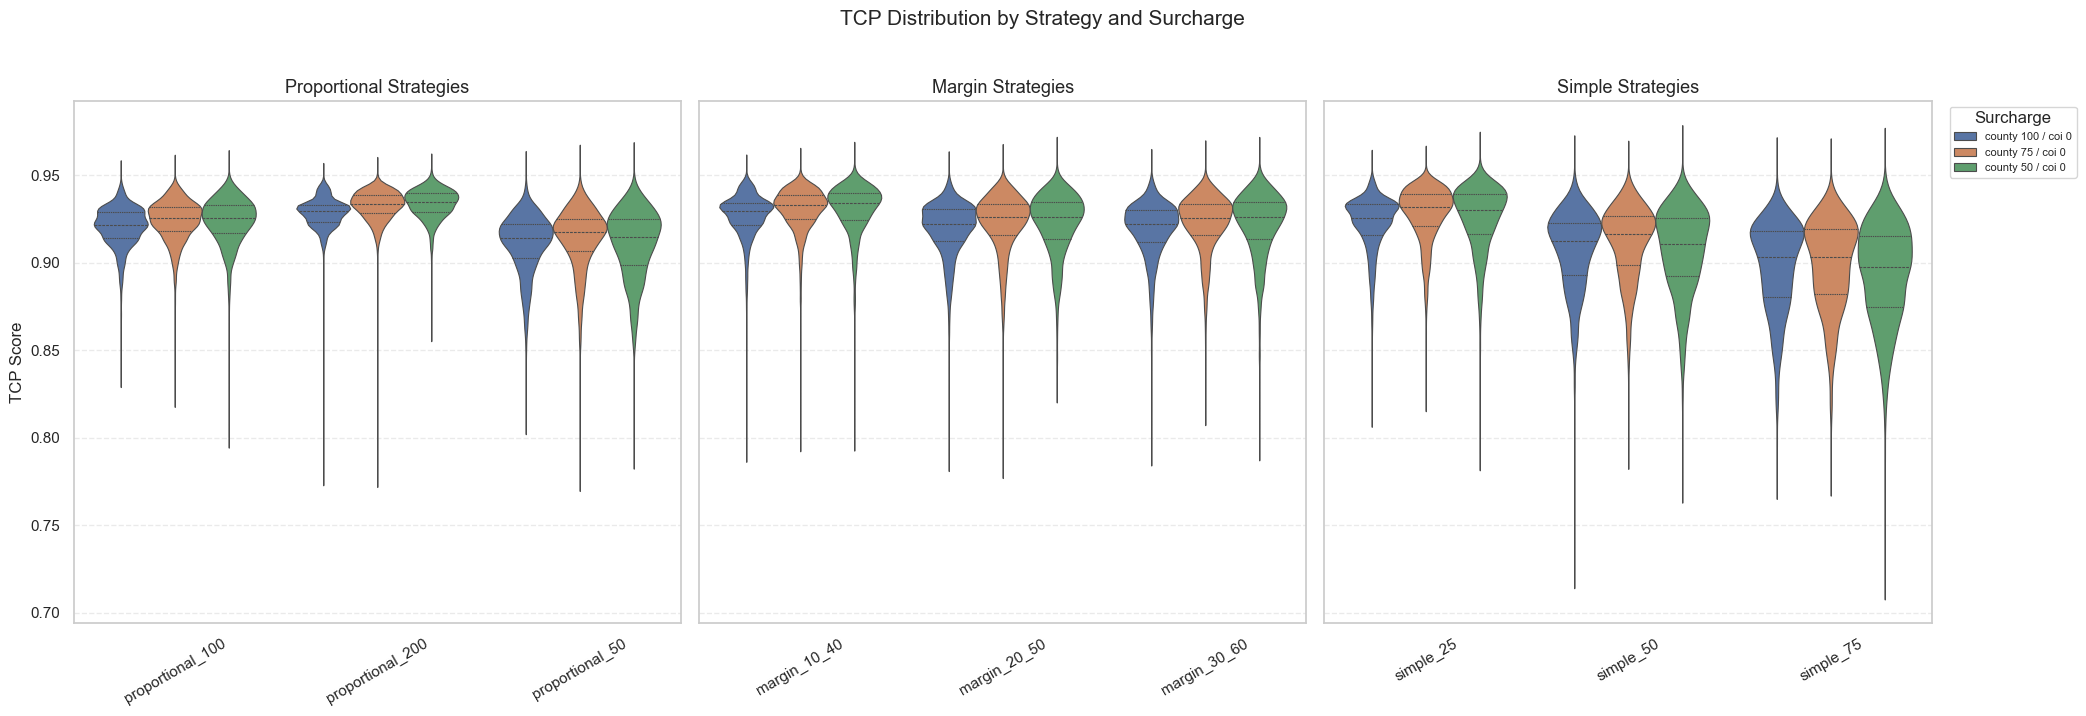

In [ ]:
obj_traces = traces[traces['objective'] == 'tcp']
if len(obj_traces) > 0:
    CLASS_ORDER = ['Proportional', 'Margin', 'Simple']
    valid_classes = [c for c in CLASS_ORDER if c in obj_traces['strategy_class'].unique()]
    
    fig, axes = plt.subplots(1, len(valid_classes), figsize=(7 * len(valid_classes), 7), sharey=True)
    if len(valid_classes) == 1:
        axes = [axes]
    
    for i, s_class in enumerate(valid_classes):
        subset = obj_traces[obj_traces['strategy_class'] == s_class].copy()
    
        ### get strategies in this class, sorted
        strats_in_class = sorted(subset['strategy'].unique())
        subset['strategy'] = pd.Categorical(subset['strategy'], categories=strats_in_class, ordered=True)
    
        sns.violinplot(
            data=subset,
            x='strategy',
            y=TCP_COL,
            hue='surcharge_label',
            ax=axes[i],
            cut=5,
            inner='quartile',
            linewidth=0.8,
            density_norm='width',
        )
    
        axes[i].set_title(f'{s_class} Strategies', fontsize=13)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=30)
        axes[i].grid(True, axis='y', linestyle='--', alpha=0.4)
    
        ### only show legend on last panel
        if i < len(valid_classes) - 1:
            axes[i].get_legend().remove()
        else:
            axes[i].legend(title='Surcharge', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    
    axes[0].set_ylabel('TCP Score')
    fig.suptitle('TCP Distribution by Strategy and Surcharge', fontsize=15, y=1.02)
    fig.tight_layout()
    plt.show()
    
    

### Objective: CS

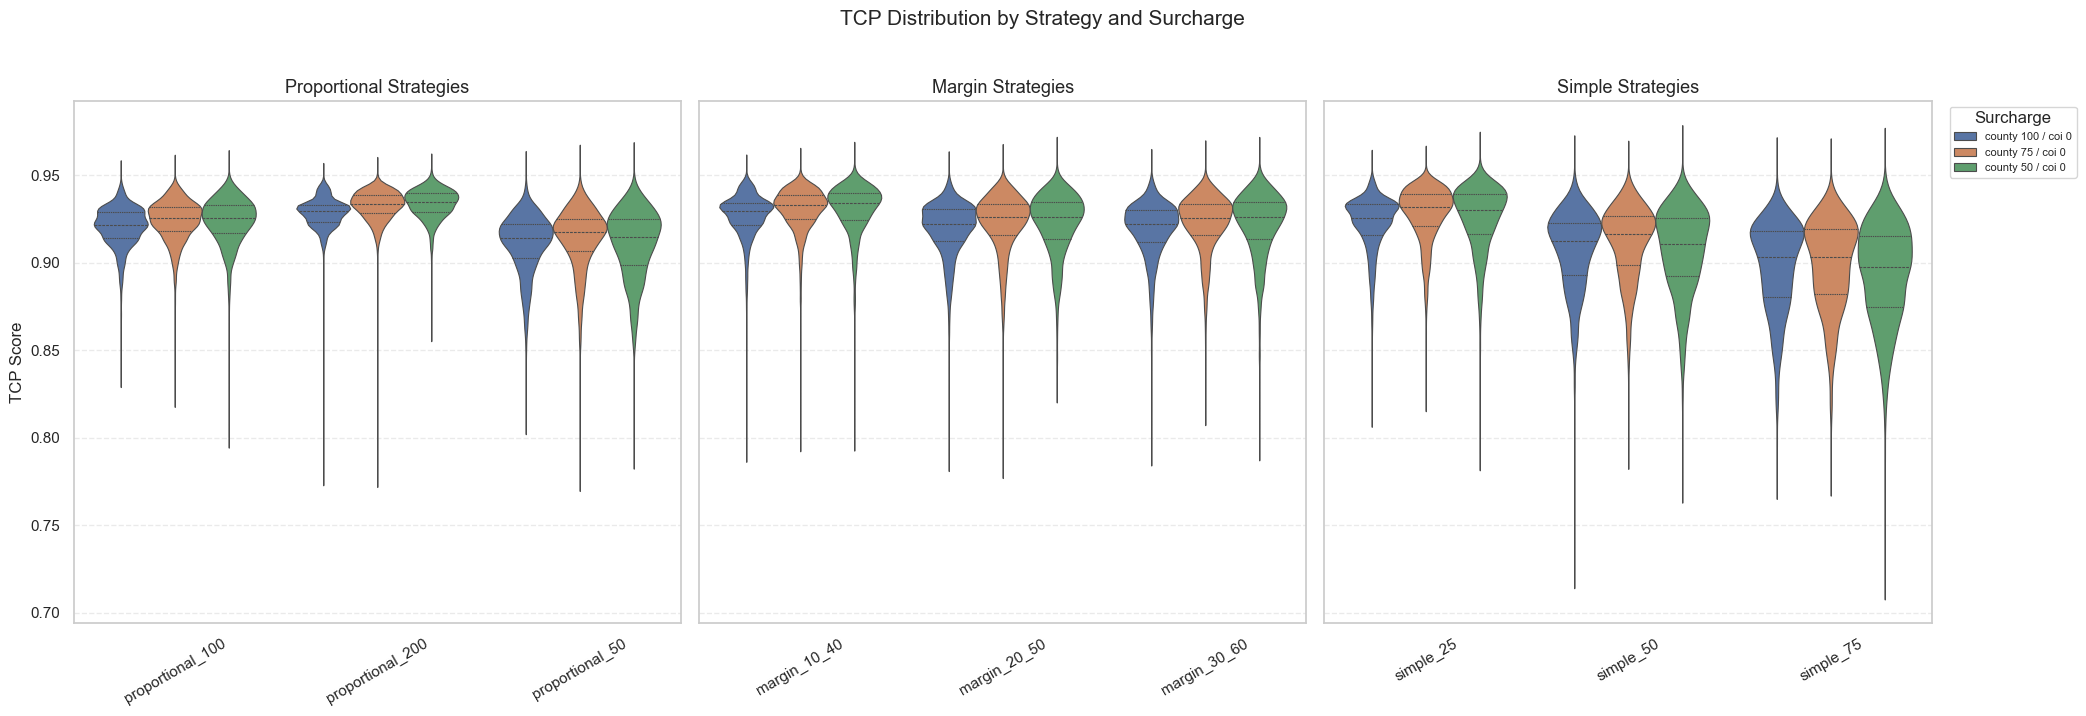

In [ ]:
obj_traces = traces[traces['objective'] == 'cs']
if len(obj_traces) > 0:
    CLASS_ORDER = ['Proportional', 'Margin', 'Simple']
    valid_classes = [c for c in CLASS_ORDER if c in obj_traces['strategy_class'].unique()]
    
    fig, axes = plt.subplots(1, len(valid_classes), figsize=(7 * len(valid_classes), 7), sharey=True)
    if len(valid_classes) == 1:
        axes = [axes]
    
    for i, s_class in enumerate(valid_classes):
        subset = obj_traces[obj_traces['strategy_class'] == s_class].copy()
    
        ### get strategies in this class, sorted
        strats_in_class = sorted(subset['strategy'].unique())
        subset['strategy'] = pd.Categorical(subset['strategy'], categories=strats_in_class, ordered=True)
    
        sns.violinplot(
            data=subset,
            x='strategy',
            y=TCP_COL,
            hue='surcharge_label',
            ax=axes[i],
            cut=5,
            inner='quartile',
            linewidth=0.8,
            density_norm='width',
        )
    
        axes[i].set_title(f'{s_class} Strategies', fontsize=13)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=30)
        axes[i].grid(True, axis='y', linestyle='--', alpha=0.4)
    
        ### only show legend on last panel
        if i < len(valid_classes) - 1:
            axes[i].get_legend().remove()
        else:
            axes[i].legend(title='Surcharge', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    
    axes[0].set_ylabel('TCP Score')
    fig.suptitle('TCP Distribution by Strategy and Surcharge', fontsize=15, y=1.02)
    fig.tight_layout()
    plt.show()
    
    

## Summary Table
aggregated stats per strategy x surcharge combination.


In [ ]:
### mean tcp by strategy x surcharge
pivot = master_df.pivot_table(
    index='strategy',
    columns='surcharge_label',
    values='mean_tcp',
    aggfunc='mean'
).round(4)

print('mean tcp by strategy x surcharge:')
display(pivot)

### same for county splits
pivot_splits = master_df.pivot_table(
    index='strategy',
    columns='surcharge_label',
    values='mean_county_splits',
    aggfunc='mean'
).round(2)

print('\nmean county splits by strategy x surcharge:')
display(pivot_splits)


mean tcp by strategy x surcharge:


surcharge_label,county 100 / coi 0,county 50 / coi 0,county 75 / coi 0
strategy,,,
margin_10_40,0.9266,0.9303,0.9302
margin_20_50,0.9191,0.9222,0.9226
margin_30_60,0.9187,0.9221,0.9224
neutral,0.8852,0.8814,NaN
proportional_100,0.9202,0.9239,0.9237
proportional_200,0.9286,0.9337,0.9326
proportional_50,0.9107,0.9114,0.9136
simple_25,0.9228,0.9251,0.9273
simple_50,0.9078,0.9076,0.9109



mean county splits by strategy x surcharge:


surcharge_label,county 100 / coi 0,county 50 / coi 0,county 75 / coi 0
strategy,,,
margin_10_40,5.67,10.84,6.77
margin_20_50,5.60,10.88,6.71
margin_30_60,5.60,10.81,6.71
neutral,5.83,11.17,NaN
proportional_100,5.54,10.89,6.66
proportional_200,5.65,11.01,6.81
proportional_50,5.58,10.92,6.64
simple_25,5.62,10.73,6.81
simple_50,5.65,10.92,6.60


## Check Mix

### Objective: TCP

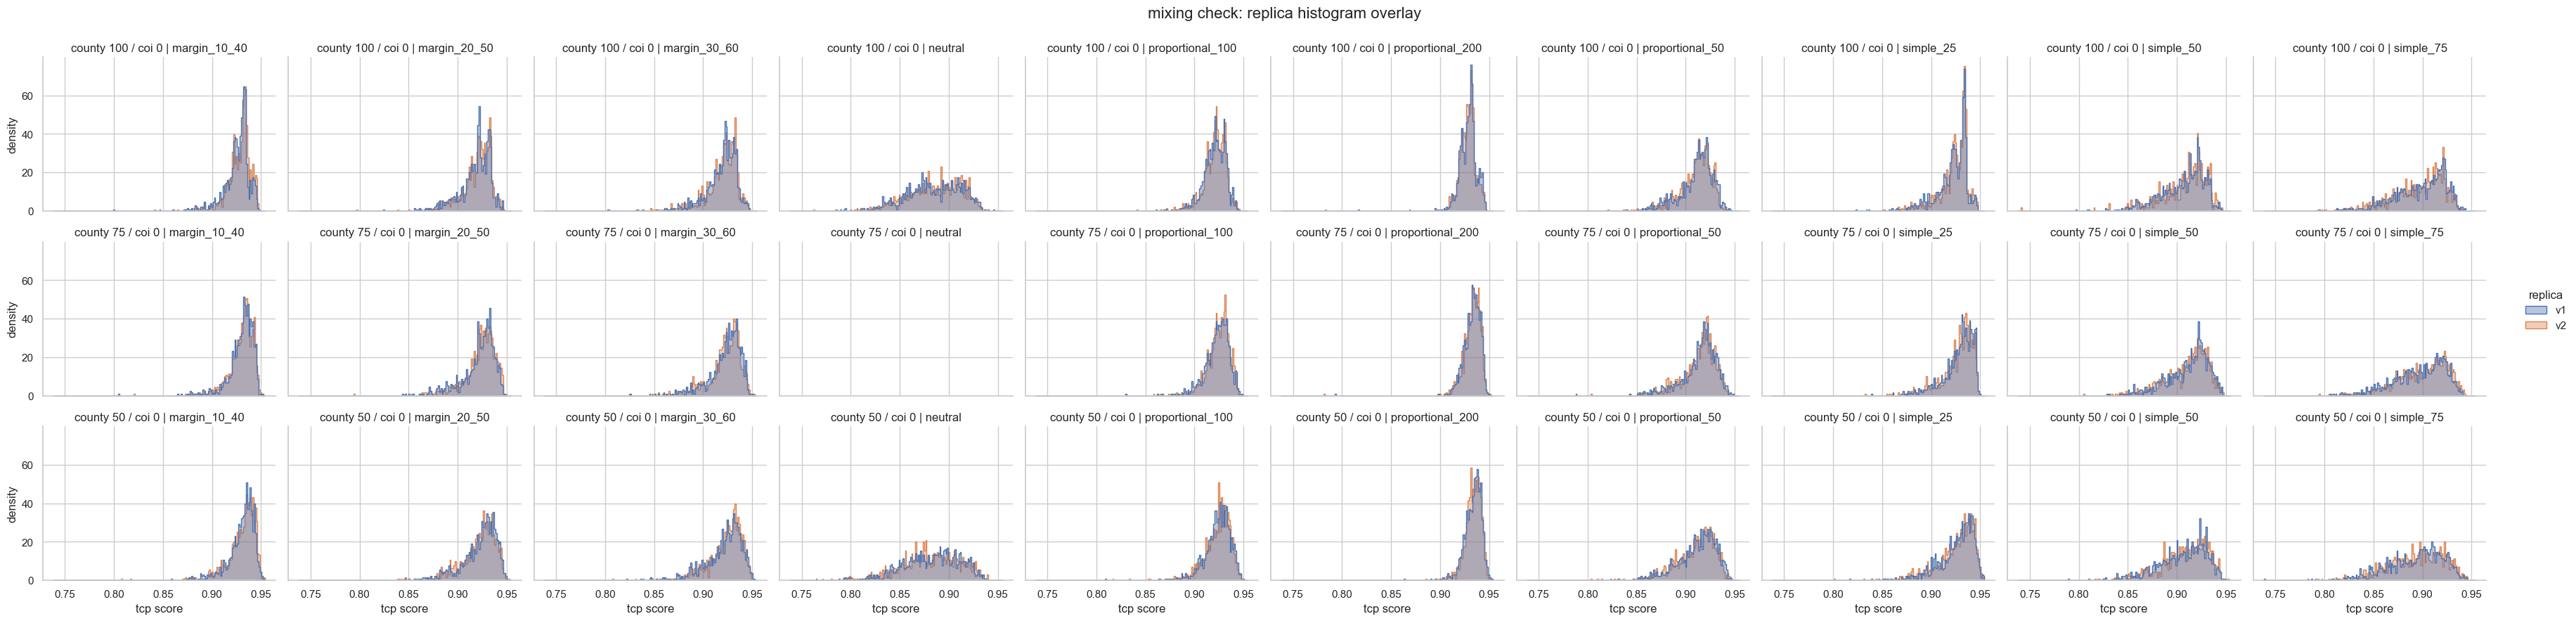

In [ ]:
obj_traces = traces[traces['objective'] == 'tcp']
if len(obj_traces) > 0:
    ### overlay tcp histograms for v1 and v2
    g = sns.displot(
        data=obj_traces,
        x=TCP_COL,
        hue='replica',
        row='surcharge_label',
        col='strategy',
        kind='hist',
        element='step',
        stat='density',
        common_norm=False,
        height=3,
        aspect=1.2,
        alpha=0.4
    )
    
    g.set_axis_labels("tcp score", "density")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle("mixing check: replica histogram overlay", fontsize=16)
    plt.show()
    
    

### Objective: CS

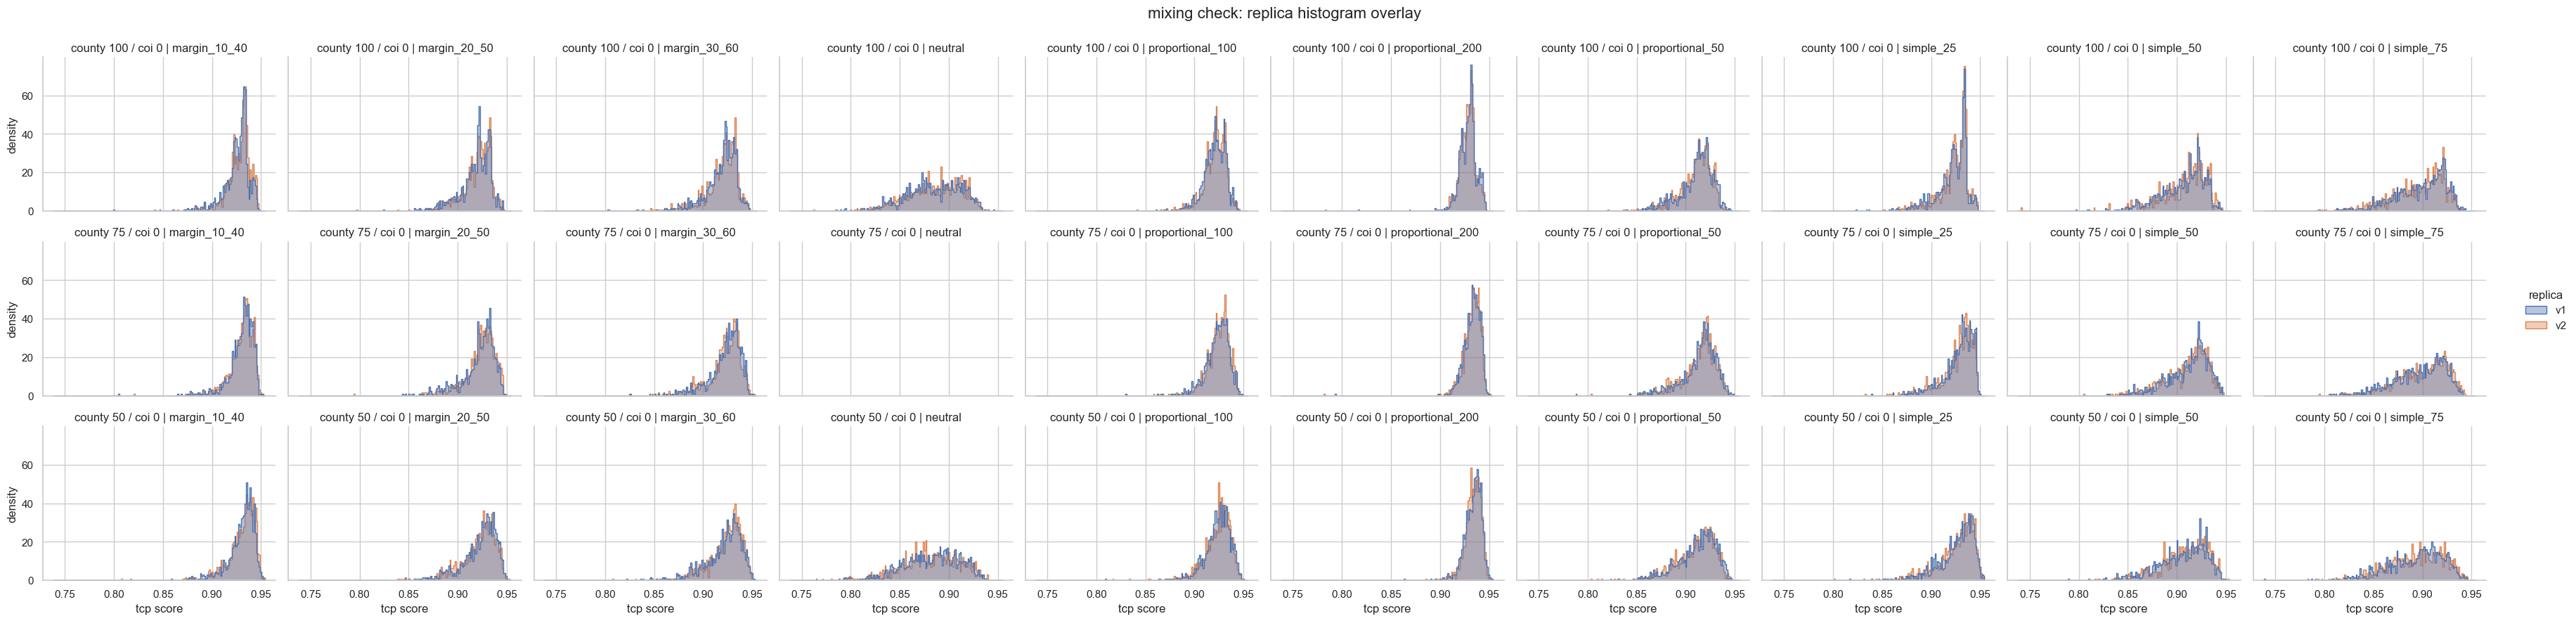

In [ ]:
obj_traces = traces[traces['objective'] == 'cs']
if len(obj_traces) > 0:
    ### overlay tcp histograms for v1 and v2
    g = sns.displot(
        data=obj_traces,
        x=TCP_COL,
        hue='replica',
        row='surcharge_label',
        col='strategy',
        kind='hist',
        element='step',
        stat='density',
        common_norm=False,
        height=3,
        aspect=1.2,
        alpha=0.4
    )
    
    g.set_axis_labels("tcp score", "density")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle("mixing check: replica histogram overlay", fontsize=16)
    plt.show()
    
    

## 7. partisan metrics: dem wins vs tcp

evaluating how the acceptance functions and surcharge constraints affect the partisan performance of the map. here we plot total tcp score against the number of democratic wins. this gives us insight into the distribution of partisan outcomes in the generated ensemble, and how preservation goals shape those outcomes.

### Objective: TCP

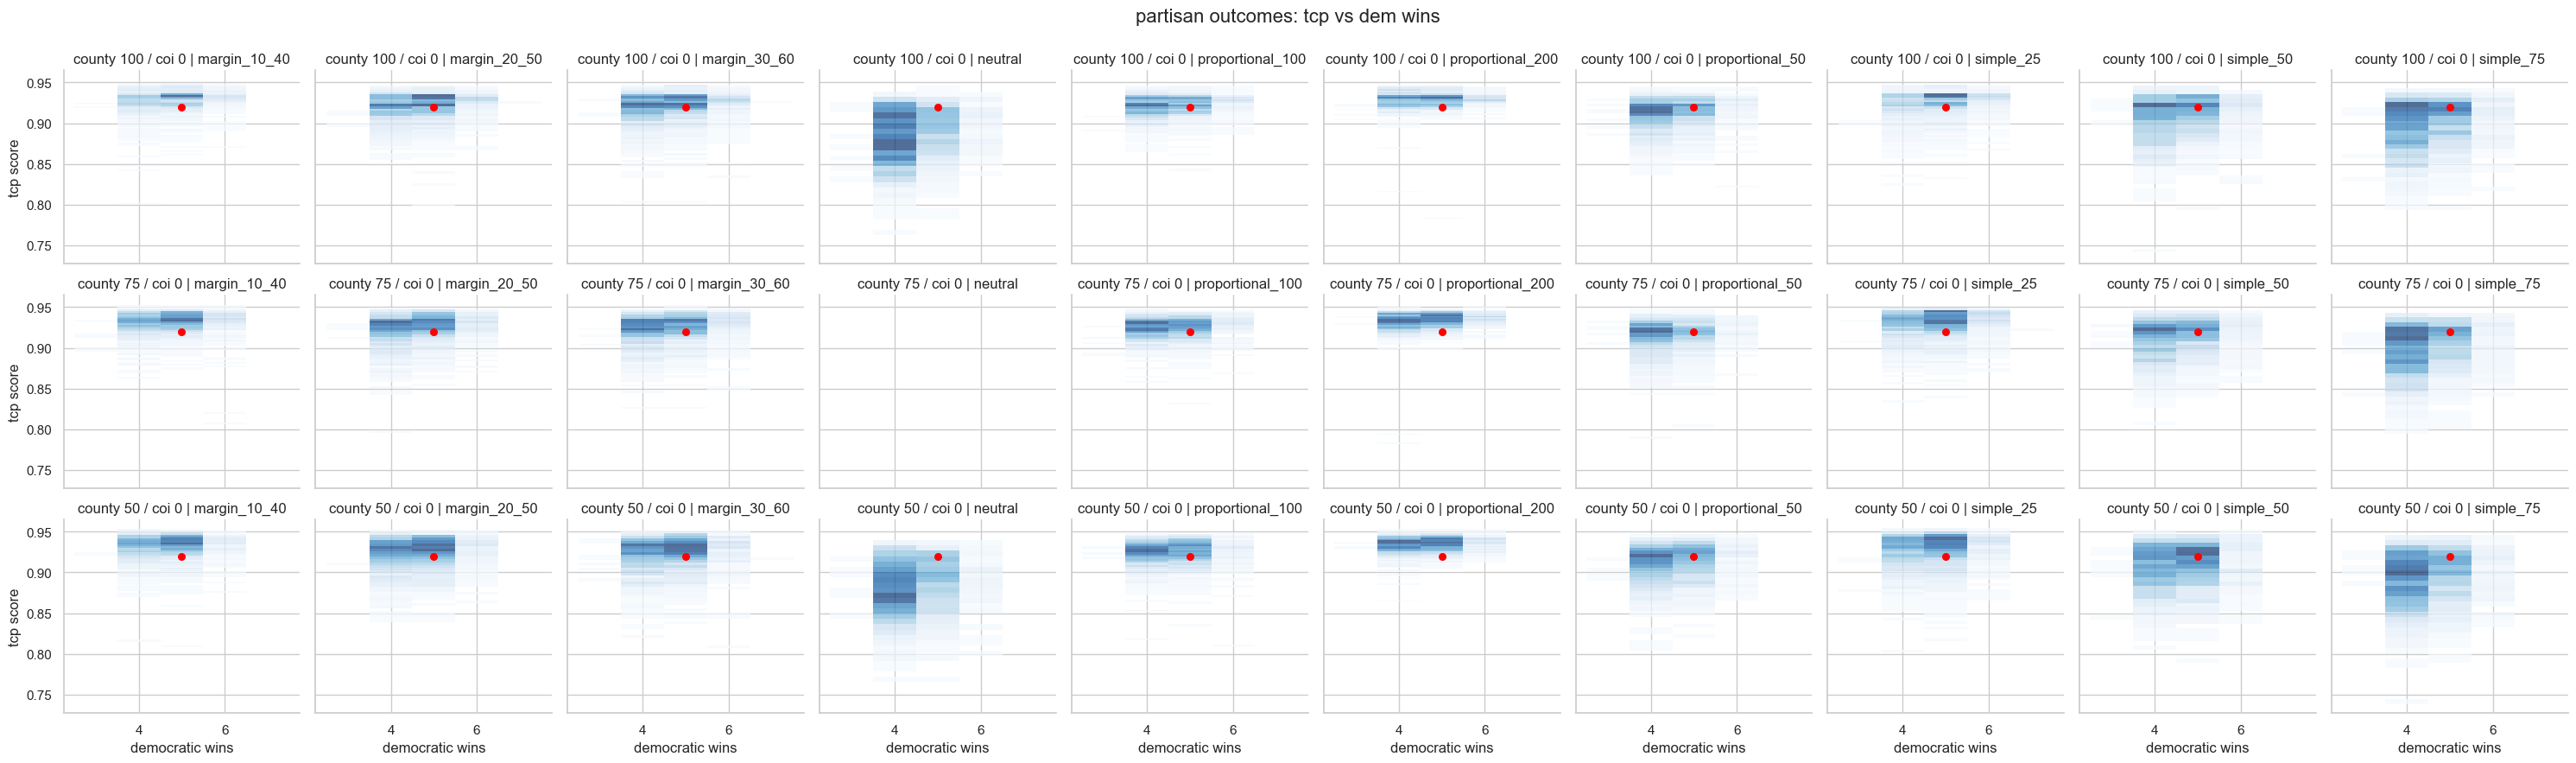

In [ ]:
obj_traces = traces[traces['objective'] == 'tcp']
if len(obj_traces) > 0:
    ### pareto frontier: tcp vs dem wins
    if 'dem_wins' in obj_traces.columns:
        g = sns.FacetGrid(
            obj_traces,
            row="surcharge_label",
            col="strategy",
        )
        g.map_dataframe(sns.histplot, x="dem_wins", y=TCP_COL, fill=True, alpha=0.7, cmap="Blues", linewidths=0, discrete=(True, False))
        g.map(plt.scatter, x=[5], y=[0.92], color="red", s=30, zorder=10, label="Enacted Plan")
        g.set_axis_labels("democratic wins", "tcp score")
        g.set_titles(row_template="{row_name}", col_template="{col_name}")
        plt.subplots_adjust(top=0.9)
        g.fig.suptitle("partisan outcomes: tcp vs dem wins", fontsize=16)
        plt.show()
    else:
        print('dem_wins not found in data')
    
    

### Objective: CS

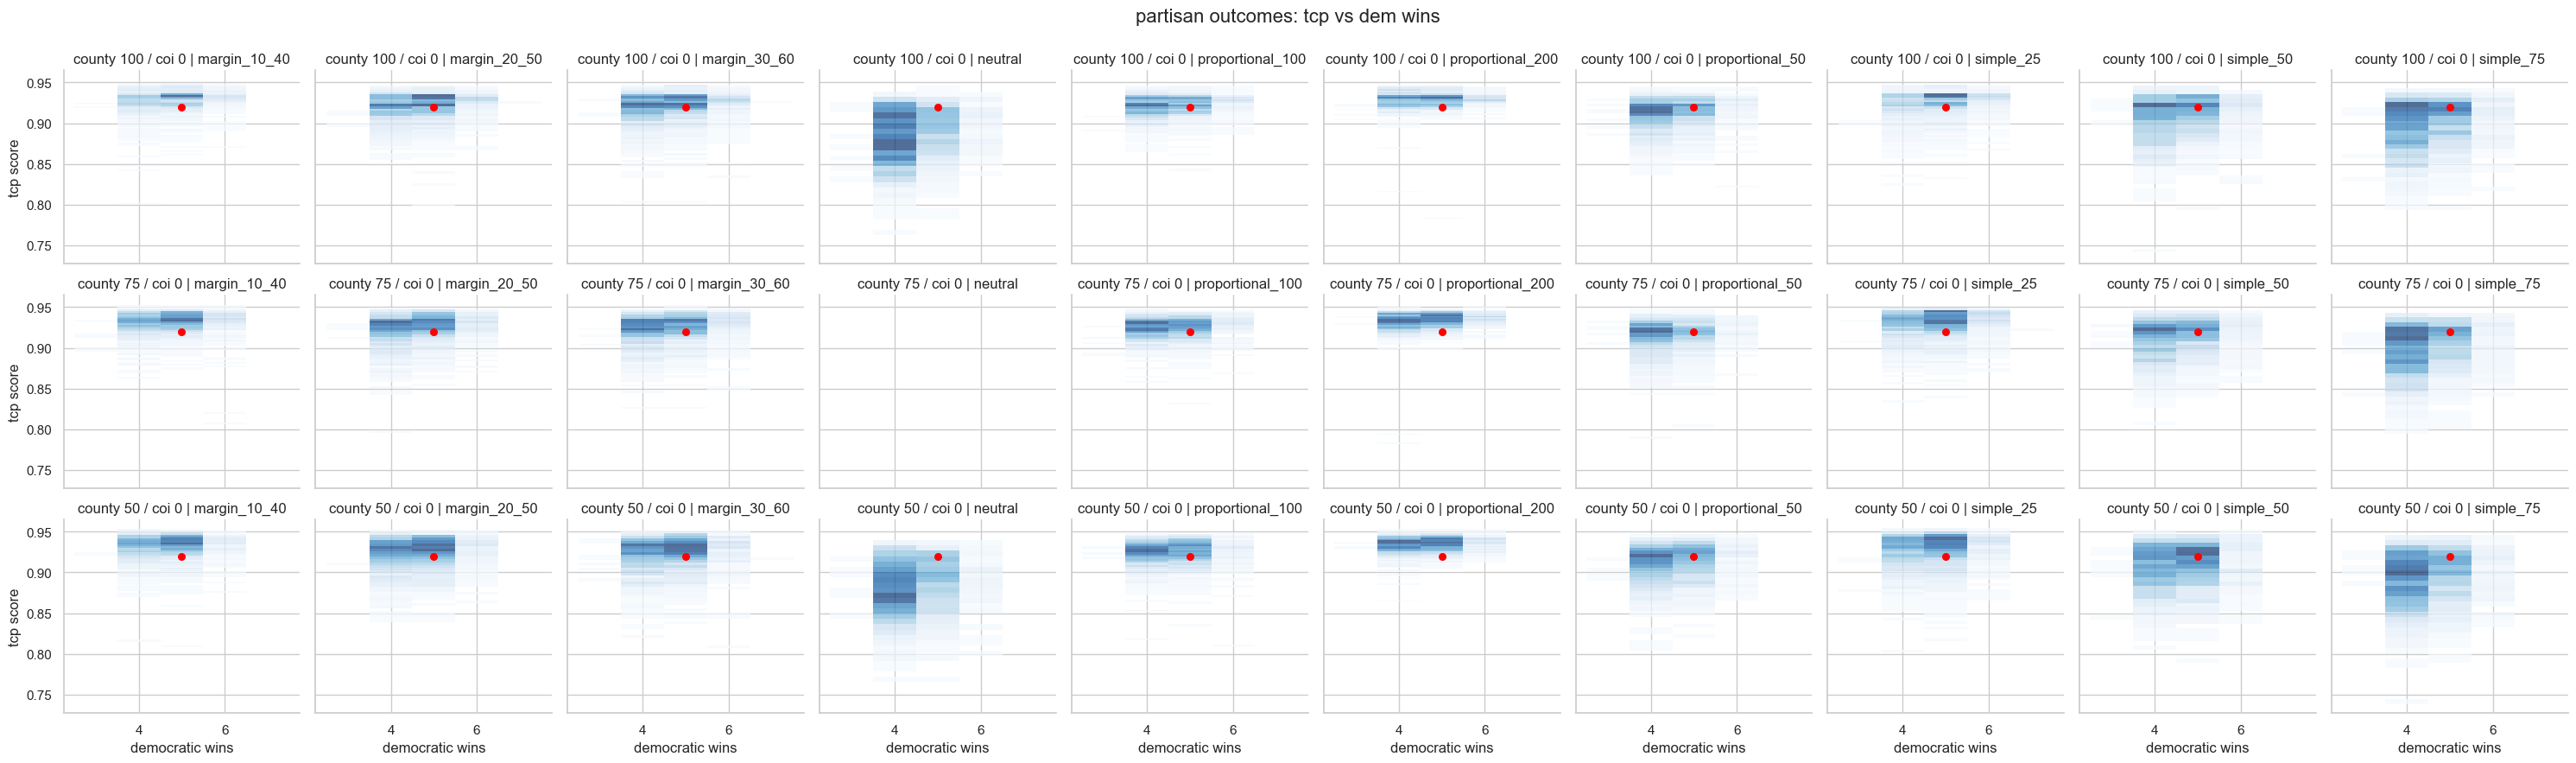

In [ ]:
obj_traces = traces[traces['objective'] == 'cs']
if len(obj_traces) > 0:
    ### pareto frontier: tcp vs dem wins
    if 'dem_wins' in obj_traces.columns:
        g = sns.FacetGrid(
            obj_traces,
            row="surcharge_label",
            col="strategy",
        )
        g.map_dataframe(sns.histplot, x="dem_wins", y=TCP_COL, fill=True, alpha=0.7, cmap="Blues", linewidths=0, discrete=(True, False))
        g.map(plt.scatter, x=[5], y=[0.92], color="red", s=30, zorder=10, label="Enacted Plan")
        g.set_axis_labels("democratic wins", "tcp score")
        g.set_titles(row_template="{row_name}", col_template="{col_name}")
        plt.subplots_adjust(top=0.9)
        g.fig.suptitle("partisan outcomes: tcp vs dem wins", fontsize=16)
        plt.show()
    else:
        print('dem_wins not found in data')
    
    

## 8. partisan metrics: mean dem share vs tcp

using the continuous mean democratic vote share (averaged across all districts) mapped against the tcp score. we use a filled kde density plot for this continuous data.

### Objective: TCP

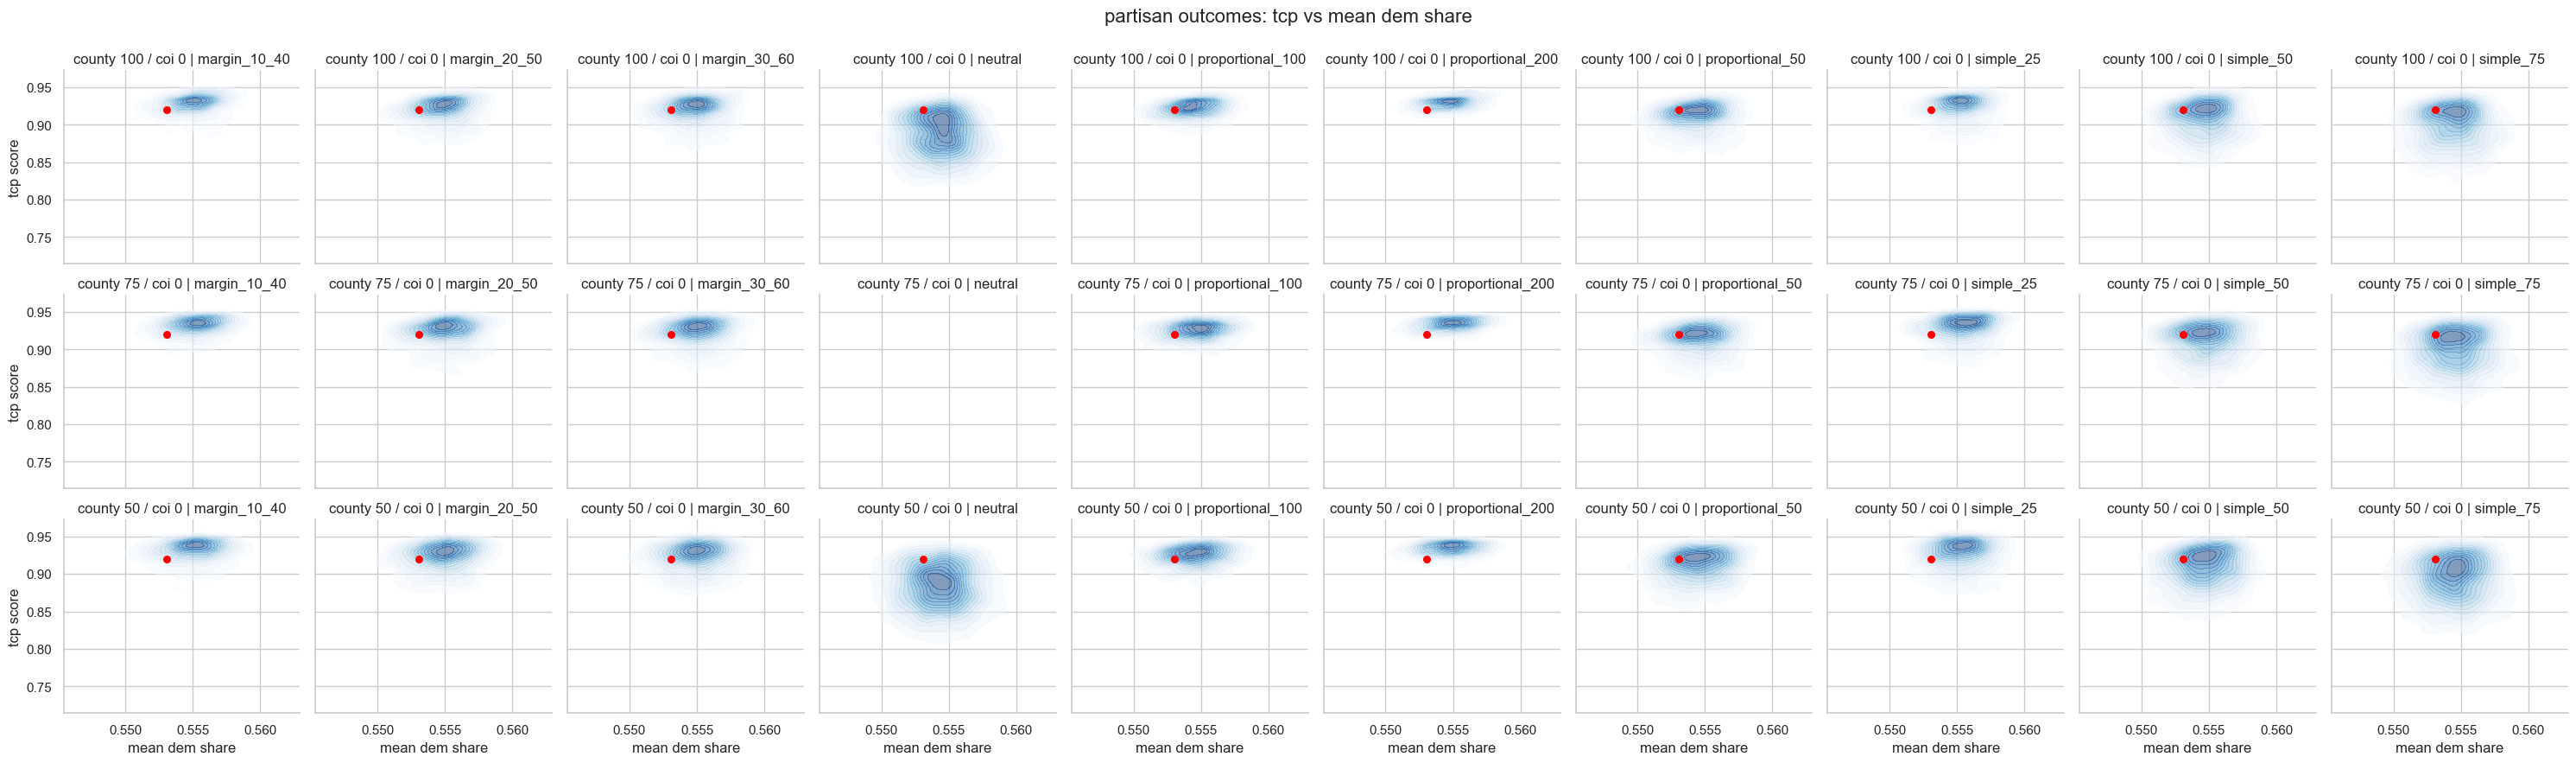

In [ ]:
obj_traces = traces[traces['objective'] == 'tcp']
if len(obj_traces) > 0:
    ### density plot: tcp vs mean dem share
    if 'mean_dem_share' in obj_traces.columns:
        g = sns.FacetGrid(
            obj_traces,
            row="surcharge_label",
            col="strategy",
        )
        g.map_dataframe(sns.kdeplot, x="mean_dem_share", y=TCP_COL, fill=True, alpha=0.5, cmap="Blues", levels=15)
        g.map(plt.scatter, x=[0.55306051436], y=[0.92], color="red", s=30, zorder=10, label="Enacted Plan")
        g.set_axis_labels("mean dem share", "tcp score")
        g.set_titles(row_template="{row_name}", col_template="{col_name}")
        plt.subplots_adjust(top=0.9)
        g.fig.suptitle("partisan outcomes: tcp vs mean dem share", fontsize=16)
        plt.show()
    else:
        print('mean_dem_share not found in data')
    
    

### Objective: CS

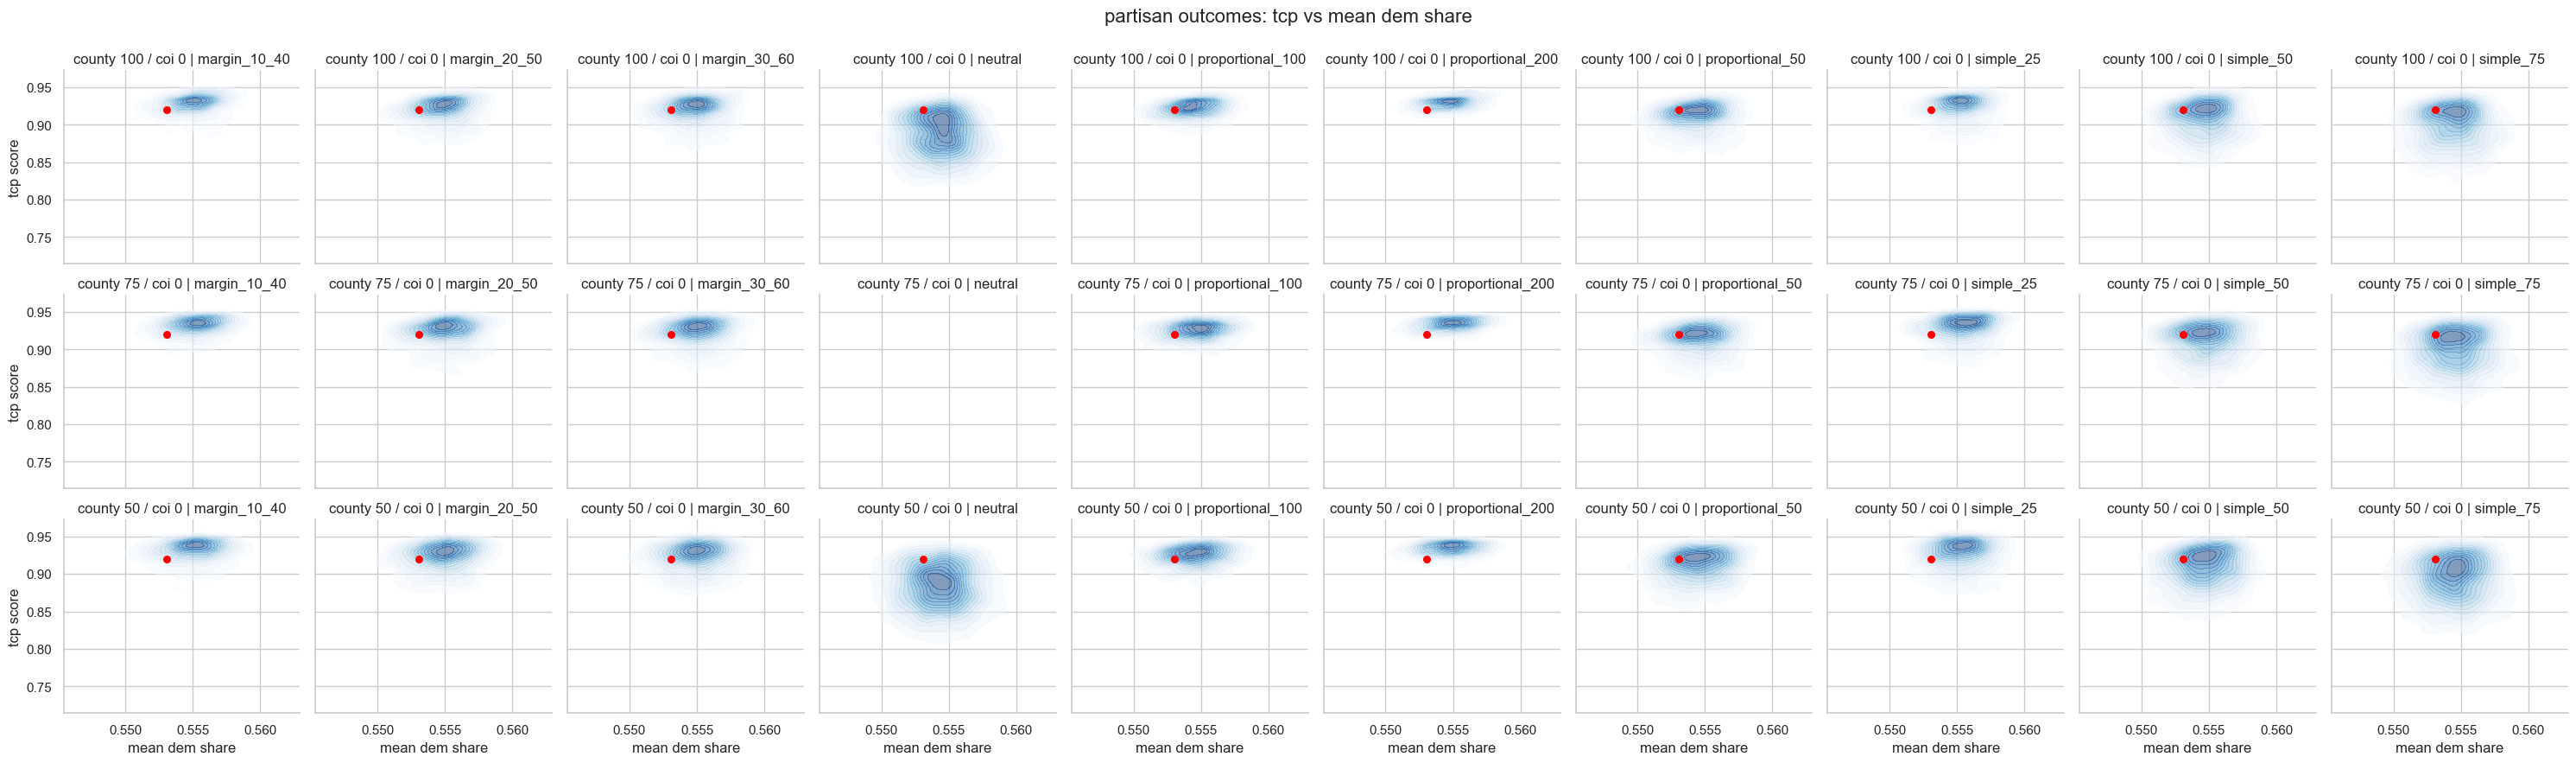

In [ ]:
obj_traces = traces[traces['objective'] == 'cs']
if len(obj_traces) > 0:
    ### density plot: tcp vs mean dem share
    if 'mean_dem_share' in obj_traces.columns:
        g = sns.FacetGrid(
            obj_traces,
            row="surcharge_label",
            col="strategy",
        )
        g.map_dataframe(sns.kdeplot, x="mean_dem_share", y=TCP_COL, fill=True, alpha=0.5, cmap="Blues", levels=15)
        g.map(plt.scatter, x=[0.55306051436], y=[0.92], color="red", s=30, zorder=10, label="Enacted Plan")
        g.set_axis_labels("mean dem share", "tcp score")
        g.set_titles(row_template="{row_name}", col_template="{col_name}")
        plt.subplots_adjust(top=0.9)
        g.fig.suptitle("partisan outcomes: tcp vs mean dem share", fontsize=16)
        plt.show()
    else:
        print('mean_dem_share not found in data')
    
    

## 7. gaming the metric: tcp vs binary community splits

this plot explores where the tcp metric diverges from the traditional "binary community splits" metric, answering two key questions:

**1. how can a map have high tcp but *terrible* (high) community splits? (bottom-right)**
- **the "nibble" effect:** if a mapmaker splits 20 communities, but splits them 95%-5% to balance population, the binary metric penalizes them 20 times. however, the tcp math ($0.95^2 + 0.05^2 = 0.905$) remains incredibly high. tcp gracefully forgives minor population-balancing nibbles, treating it as a feature, not a bug.

**2. how can a map have low tcp but *good* (low) community splits? (top-left)**
- **the "perfect destruction" effect:** if a mapmaker only splits 5 communities, the binary metric looks great. but if those 5 communities are split exactly 50%-50%, the tcp math plummets ($0.5^2 + 0.5^2 = 0.5$). additionally, if those 5 perfectly destroyed communities are heavily weighted/high-priority, the overall tcp score will tank despite the low raw count of splits.


### Objective: TCP

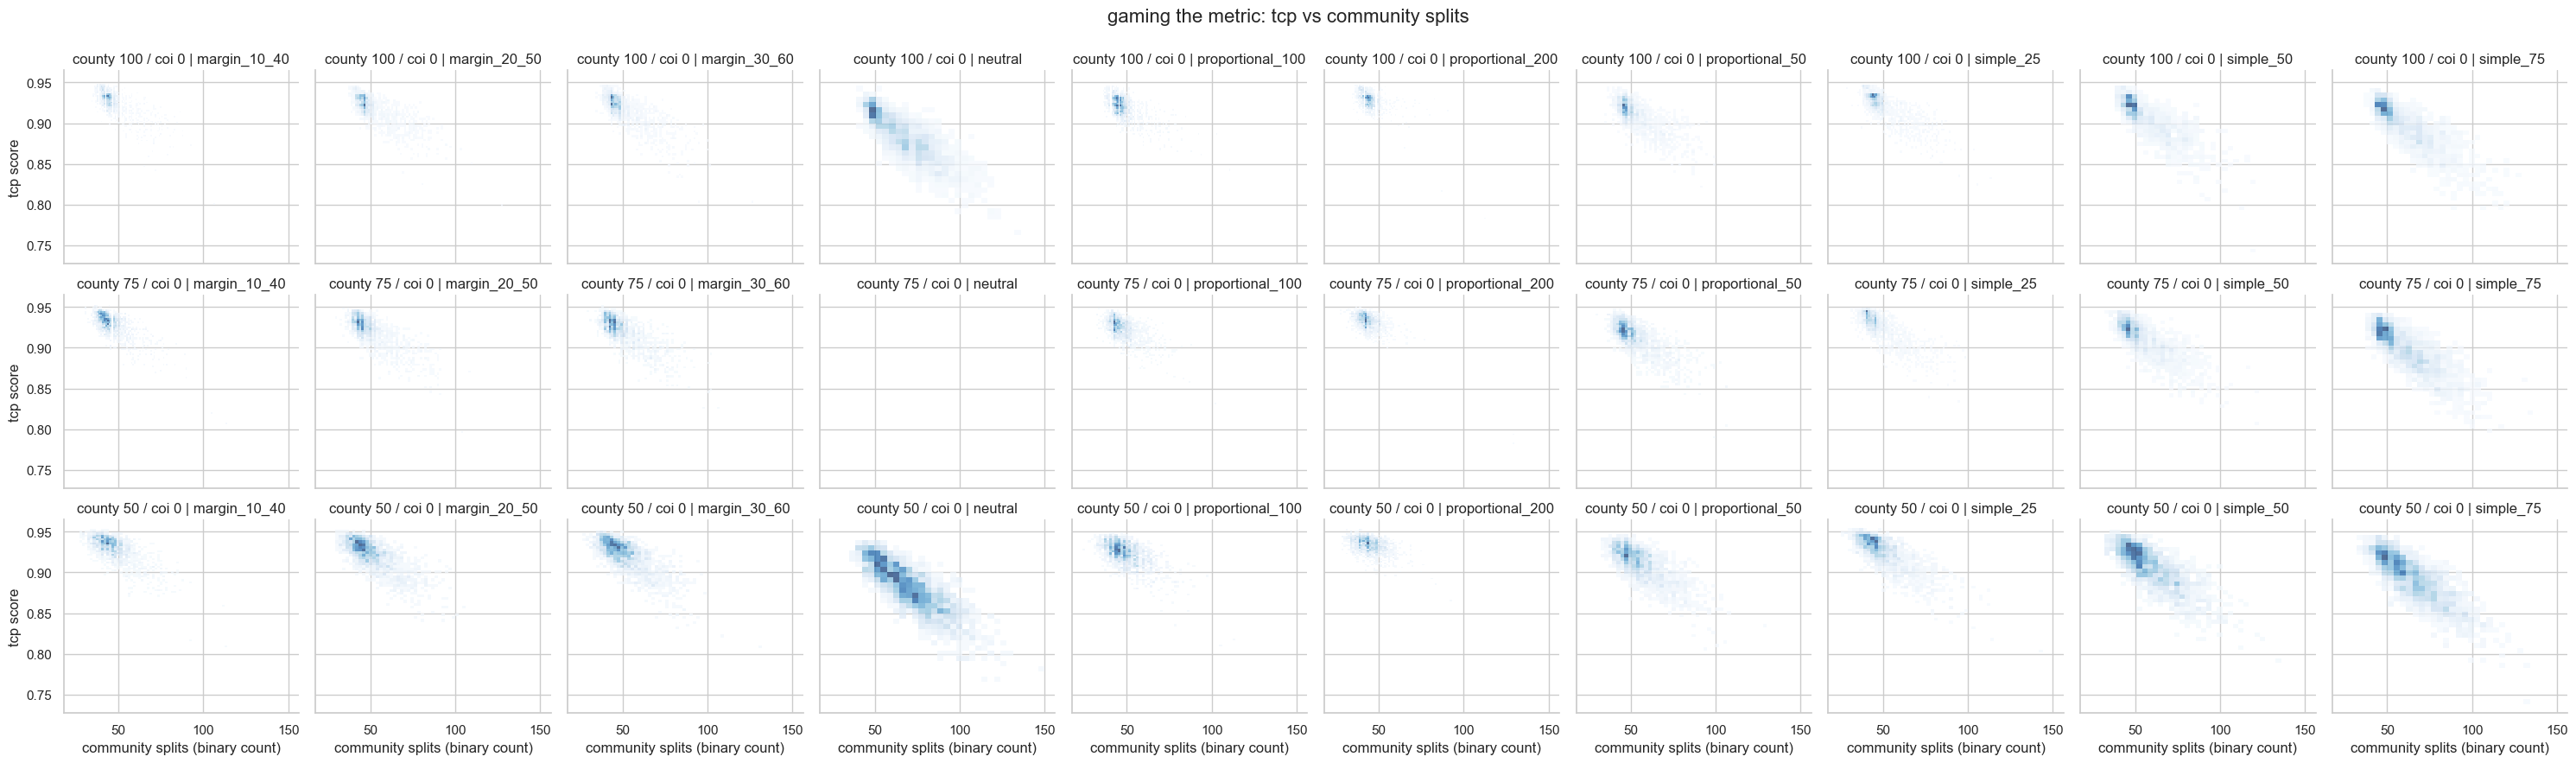

In [ ]:
obj_traces = traces[traces['objective'] == 'tcp']
if len(obj_traces) > 0:
    ### tcp vs community splits to identify gaming regions
    g = sns.FacetGrid(
        obj_traces,
        row="surcharge_label",
        col="strategy",
        height=3,
        aspect=1
    )
    g.map_dataframe(sns.histplot, x="communities_split", y=TCP_COL, fill=True, alpha=0.7, cmap="Blues", linewidths=0)
    
    g.set_axis_labels("community splits (binary count)", "tcp score")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle("gaming the metric: tcp vs community splits", fontsize=16)
    plt.show()
    
    

### Objective: CS

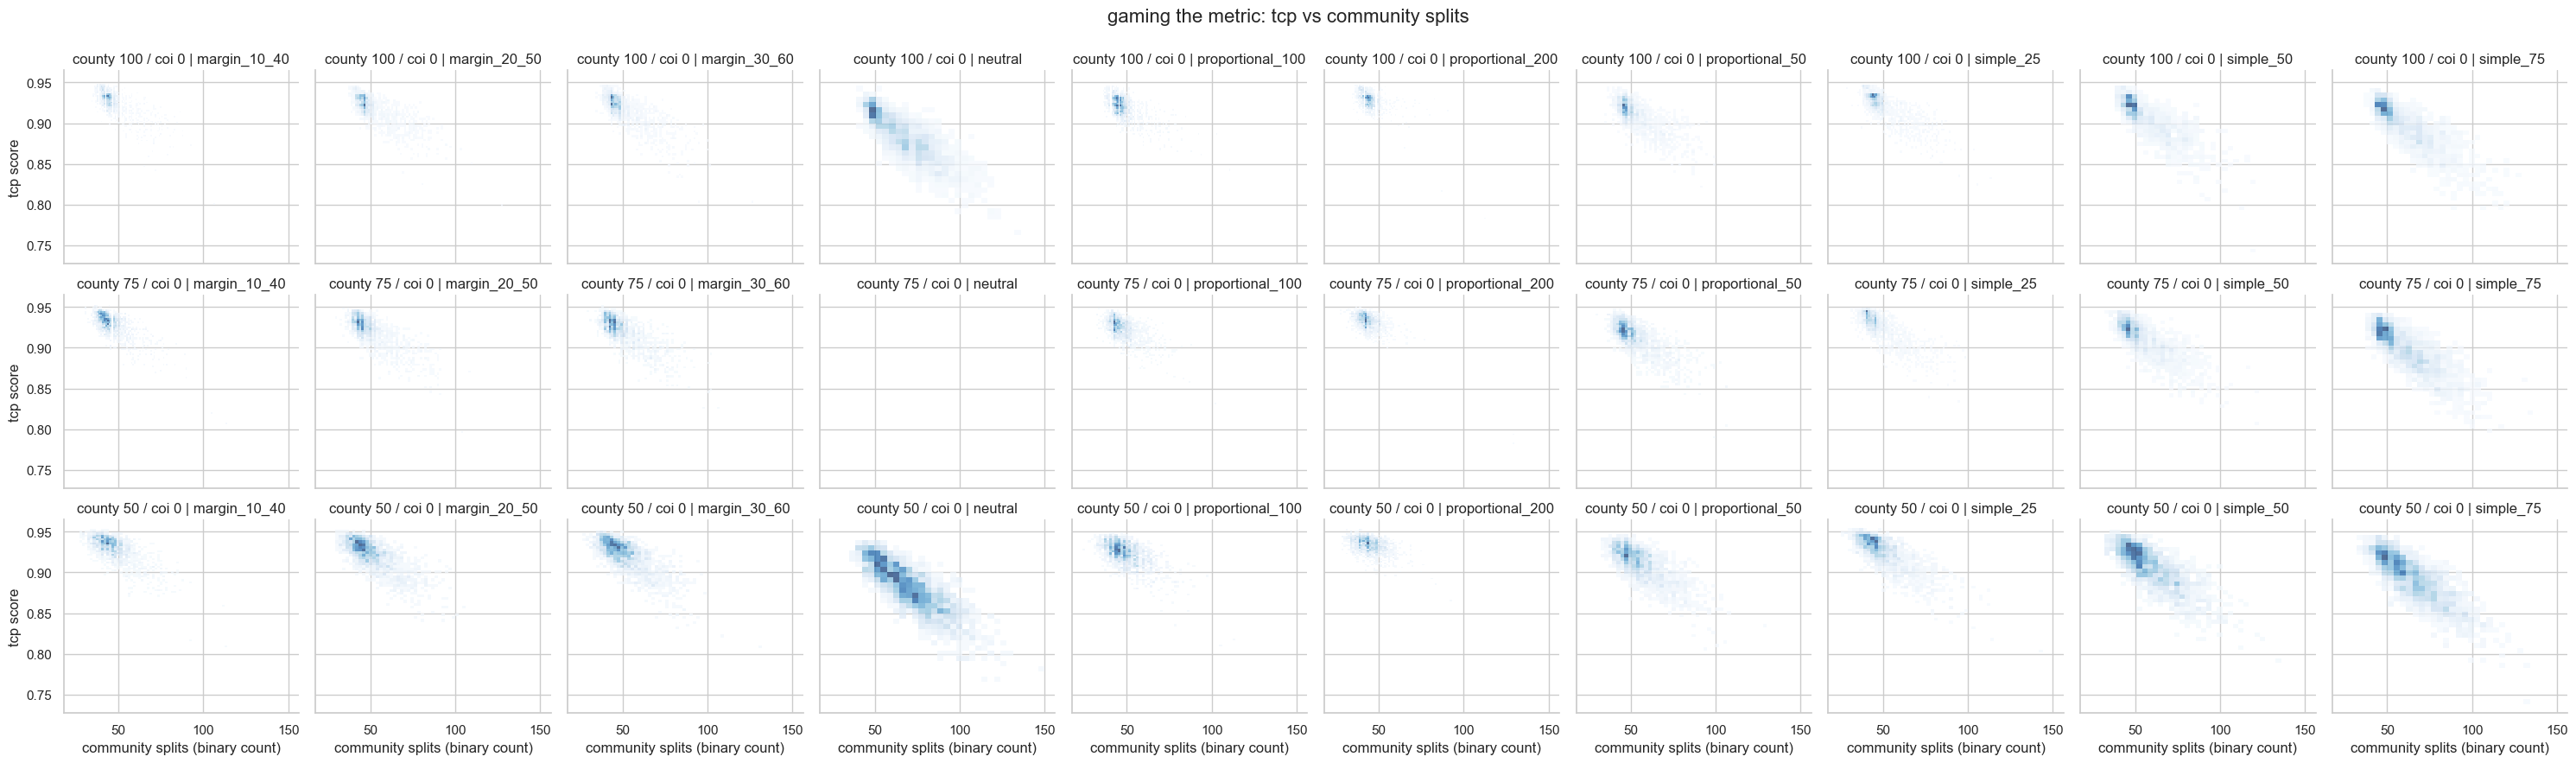

In [ ]:
obj_traces = traces[traces['objective'] == 'cs']
if len(obj_traces) > 0:
    ### tcp vs community splits to identify gaming regions
    g = sns.FacetGrid(
        obj_traces,
        row="surcharge_label",
        col="strategy",
        height=3,
        aspect=1
    )
    g.map_dataframe(sns.histplot, x="communities_split", y=TCP_COL, fill=True, alpha=0.7, cmap="Blues", linewidths=0)
    
    g.set_axis_labels("community splits (binary count)", "tcp score")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle("gaming the metric: tcp vs community splits", fontsize=16)
    plt.show()
    
    

### the smoking gun: why binary splits are insufficient

if you look closely at the `neutral` column (baseline mcmc), the vertical thickness or "spread" of the data blob is massive. for example, you can have two completely different maps that **both have exactly 75 binary community splits**.
- map a: tcp = 0.88 (the 75 communities were heavily fractured/destroyed)
- map b: tcp = 0.92 (the 75 communities were mostly just "nibbled" on their edges for population balance)

this proves to advisor 1 and 2 that binary splits are a **blunt instrument**. counting binary splits treats a 50-50 destruction identically to a 95-5 nibble. 

when we look at the optimized strategies (e.g., `margin_10_40`), we see the algorithm actively fighting this. even when population constraints force the map to split communities (moving right on the x-axis), the optimized strategies pull the blob *upwards*, ensuring those unavoidable splits are only edge-nibbles, preserving the high tcp score.